# Django Ecosystem Code Graph — Exploratory Data Analysis

This notebook explores a **heterogeneous directed code graph** built from 13 Django-ecosystem repositories.

The graph is stored in `django_ecosystem_v1.json` and contains:
- **Nodes** (5 types): `repo`, `file`, `module`, `class`, `function`  
- **Edges** (8 types): `CONTAINS_FILE`, `IMPLEMENTS_MODULE`, `DEFINES_CLASS`, `DEFINES_FUNCTION`, `DEFINES_METHOD`, `IMPORTS_MODULE`, `INHERITS`, `CALLS`

**Node ID format:** `<type_prefix>::<repo_name>::<module>::<qualname>`

---

In [12]:
# ── Cell 0: Setup & Imports ──────────────────────────────────
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore", category=FutureWarning)

# Display / style settings
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

DATA_PATH = Path("django_ecosystem_v1.json")
print(f"Data file: {DATA_PATH}  (exists={DATA_PATH.exists()})")
print(f"Libraries: pandas {pd.__version__}, numpy {np.__version__}, "
      f"matplotlib {plt.matplotlib.__version__}, seaborn {sns.__version__}, "
      f"networkx {nx.__version__}")

Data file: django_ecosystem_v1.json  (exists=True)
Libraries: pandas 3.0.1, numpy 2.4.3, matplotlib 3.10.8, seaborn 0.13.2, networkx 3.6.1


## 1 — Load JSON & Build Core DataFrames

Load the full graph once. Flatten node features into top-level columns alongside `id` and `type`. Extract a `repo` column from the node ID (second `::` segment).

In [13]:
# ── Cell 1: Load JSON & build DataFrames ─────────────────────
import time as _t
_t0 = _t.perf_counter()

with open(DATA_PATH) as f:
    raw = json.load(f)

_elapsed = _t.perf_counter() - _t0
print(f"Loaded in {_elapsed:.1f}s")

metadata = raw["metadata"]
print(f"\nMetadata keys: {list(metadata.keys())}")
print(f"  created_at : {metadata.get('created_at', 'N/A')}")
print(f"  repos      : {[r['name'] for r in metadata.get('repos', [])]}")

# ── Nodes DataFrame ──
rows = []
for n in raw["nodes"]:
    row = {"id": n["id"], "type": n["type"]}
    row.update(n.get("features", {}))
    rows.append(row)

nodes_df = pd.DataFrame(rows)
# Extract repo name from ID:  <prefix>::<repo>::...
nodes_df["repo"] = nodes_df["id"].str.split("::").str[1]

# ── Edges DataFrame ──
edges_df = pd.DataFrame(raw["edges"])
# Extract source/target repo
edges_df["source_repo"] = edges_df["source"].str.split("::").str[1]
edges_df["target_repo"] = edges_df["target"].str.split("::").str[1]
edges_df["is_cross_repo"] = edges_df["source_repo"] != edges_df["target_repo"]

# Free raw JSON to save memory
del raw

print(f"\nnodes_df : {nodes_df.shape[0]:,} rows × {nodes_df.shape[1]} cols  "
      f"({nodes_df.memory_usage(deep=True).sum() / 1e6:.1f} MB)")
print(f"edges_df : {edges_df.shape[0]:,} rows × {edges_df.shape[1]} cols  "
      f"({edges_df.memory_usage(deep=True).sum() / 1e6:.1f} MB)")
print(f"\nNode types : {sorted(nodes_df['type'].unique())}")
print(f"Edge types : {sorted(edges_df['type'].unique())}")
print(f"Repos      : {sorted(nodes_df['repo'].unique())}")
print(f"\n--- nodes_df sample ---")
nodes_df.head(3)

Loaded in 2.1s

Metadata keys: ['repos', 'created_at', 'repo_name', 'repo_root']
  created_at : 2026-03-13T19:47:18.197715+00:00
  repos      : ['django', 'drf', 'wagtail', 'allauth', 'netbox', 'saleor', 'oscar', 'filter', 'simplejwt', 'drf_spectacular', 'guardian', 'celery_beat', 'channels']

nodes_df : 132,204 rows × 61 cols  (208.3 MB)
edges_df : 279,733 rows × 6 cols  (113.1 MB)

Node types : ['class', 'file', 'function', 'module', 'repo']
Edge types : ['CALLS', 'CONTAINS_FILE', 'DEFINES_CLASS', 'DEFINES_FUNCTION', 'DEFINES_METHOD', 'IMPLEMENTS_MODULE', 'IMPORTS_MODULE', 'INHERITS']
Repos      : ['allauth', 'celery_beat', 'channels', 'django', 'drf', 'drf_spectacular', 'filter', 'guardian', 'netbox', 'oscar', 'saleor', 'simplejwt', 'wagtail']

--- nodes_df sample ---


,id,type,pagerank,hub_score,authority_score,leiden_community,num_methods,num_bases,inheritance_depth,num_decorators,has_docstring,docstring_length,num_class_vars,is_abstract,is_nested,num_dunder_methods,line_span,in_degree,out_degree,embedding_input,loc,byte_size,path_depth,is_init,is_test,num_top_level_stmts,num_params,has_varargs,has_kwargs,num_defaults,...,type_hint_coverage,is_async,is_staticmethod,is_classmethod,is_property,is_abstractmethod,is_dunder,is_private,body_stmt_count,num_local_vars,num_returns,num_yields,num_raises,nesting_depth,cyclomatic_complexity,num_calls_made,num_imports,num_import_names,num_classes_defined,num_functions_defined,num_global_vars,import_fan_out,import_fan_in,num_files,num_modules,num_classes,num_functions,total_loc,num_packages,repo
0,class::allauth::allauth.account.adapter::DefaultAccountAdapter,class,0.0000,0.0000,0.0000,189,71.0000,1.0000,1.0000,0.0000,True,303.0000,1.0000,False,False,0.0000,941.0000,7.0000,72.0000,DefaultAccountAdapter | error_messages stash_verified_email unstash_verified...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,allauth
1,class::allauth::allauth.account.admin::EmailAddressAdmin,class,0.0000,-0.0000,0.0000,-1,2.0000,1.0000,0.0000,0.0000,False,0.0000,6.0000,False,False,0.0000,34.0000,1.0000,2.0000,EmailAddressAdmin | list_display list_filter search_fields raw_id_fields act...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,allauth
2,class::allauth::allauth.account.admin::EmailConfirmationAdmin,class,0.0000,-0.0000,0.0000,-1,0.0000,1.0000,0.0000,0.0000,False,0.0000,3.0000,False,False,0.0000,4.0000,1.0000,0.0000,EmailConfirmationAdmin | list_display list_filter raw_id_fields,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,allauth


## 2 — Basic Inventory & Type Distributions

Report total counts, type breakdowns, feature completeness, and check for duplicates.

Total nodes : 132,204
Total edges : 279,733
Unique node types: 5
Unique edge types: 8
Unique repos     : 13
Duplicate node IDs: 0


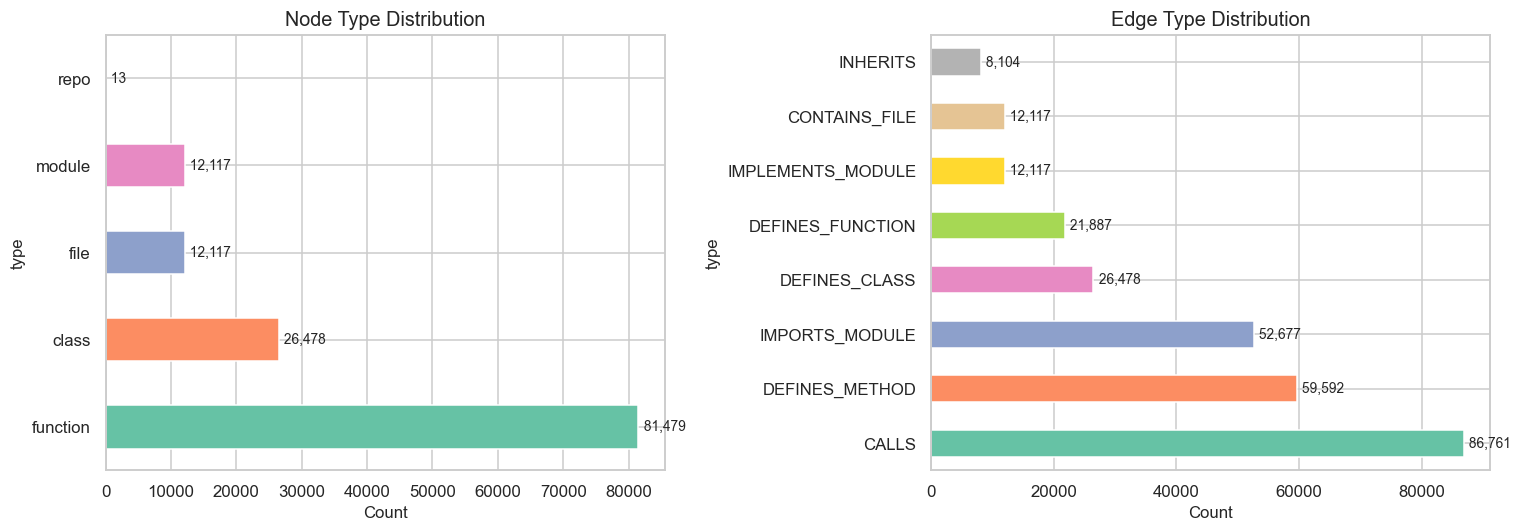


── Feature completeness (non-null count / total) per node type ──

  class (26,478 nodes) — 17 features with data:
    authority_score                 26,478 / 26,478
    docstring_length                26,478 / 26,478
    has_docstring                   26,478 / 26,478
    hub_score                       26,478 / 26,478
    in_degree                       26,478 / 26,478
    inheritance_depth               26,478 / 26,478
    is_abstract                     26,478 / 26,478
    is_nested                       26,478 / 26,478
    leiden_community                26,478 / 26,478
    line_span                       26,478 / 26,478
    num_bases                       26,478 / 26,478
    num_class_vars                  26,478 / 26,478
    num_decorators                  26,478 / 26,478
    num_dunder_methods              26,478 / 26,478
    num_methods                     26,478 / 26,478
    out_degree                      26,478 / 26,478
    pagerank                        26,478 / 26,478


In [14]:
# ── Cell 2: Basic Inventory & Type Distributions ─────────────

# --- Counts ---
print(f"Total nodes : {len(nodes_df):,}")
print(f"Total edges : {len(edges_df):,}")
print(f"Unique node types: {nodes_df['type'].nunique()}")
print(f"Unique edge types: {edges_df['type'].nunique()}")
print(f"Unique repos     : {nodes_df['repo'].nunique()}")
dup_ids = nodes_df["id"].duplicated().sum()
print(f"Duplicate node IDs: {dup_ids}")

# --- Type distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

node_counts = nodes_df["type"].value_counts()
node_counts.plot.barh(ax=axes[0], color=sns.color_palette("Set2", len(node_counts)))
axes[0].set_title("Node Type Distribution")
axes[0].set_xlabel("Count")
for i, v in enumerate(node_counts):
    axes[0].text(v + 200, i, f" {v:,}", va="center", fontsize=9)

edge_counts = edges_df["type"].value_counts()
edge_counts.plot.barh(ax=axes[1], color=sns.color_palette("Set2", len(edge_counts)))
axes[1].set_title("Edge Type Distribution")
axes[1].set_xlabel("Count")
for i, v in enumerate(edge_counts):
    axes[1].text(v + 200, i, f" {v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# --- Feature completeness per node type ---
print("\n── Feature completeness (non-null count / total) per node type ──")
exclude_cols = {"id", "type", "repo", "embedding_input"}
for ntype in sorted(nodes_df["type"].unique()):
    subset = nodes_df[nodes_df["type"] == ntype]
    feat_cols = [c for c in subset.columns if c not in exclude_cols]
    non_null = subset[feat_cols].notna().sum()
    # Only show columns that have at least 1 non-null
    present = non_null[non_null > 0].sort_index()
    n = len(subset)
    print(f"\n  {ntype} ({n:,} nodes) — {len(present)} features with data:")
    for col, cnt in present.items():
        pct = cnt / n * 100
        marker = "" if pct > 99.9 else f"  ⚠ {pct:.1f}%"
        print(f"    {col:<30s} {cnt:>7,} / {n:,}{marker}")

## 3 — Per-Repo Breakdown

Nodes by type per repo, total LOC (summing function `loc`), and cross-repo edge ratios.

,class,file,function,module,repo,total,total_func_loc,cross_repo_edges_out,cross_repo_edges_in,total_edges_out,cross_repo_ratio_out
repo,,,,,,,,,,,
django,7889,2890,29418,2890,1,43088,"377,250",4,"23,037","84,664",0.0%
saleor,5426,4207,20848,4207,1,34689,"576,607","8,055",0,"92,527",8.7%
wagtail,3184,1247,12085,1247,1,17764,"174,434","5,960",0,"36,655",16.3%
netbox,5390,1090,5604,1090,1,13175,"82,481","3,654",0,"20,145",18.1%
oscar,1571,823,4146,823,1,7364,"40,927","2,400",0,"11,136",21.6%
allauth,967,1275,3548,1275,1,7066,"37,680","1,756",5,"15,270",11.5%
drf,1065,158,2741,158,1,4123,"30,413",730,"1,283","8,035",9.1%
drf_spectacular,252,97,783,97,1,1230,"12,820",870,180,"3,692",23.6%
guardian,215,131,715,131,1,1193,"9,516",521,3,"2,810",18.5%


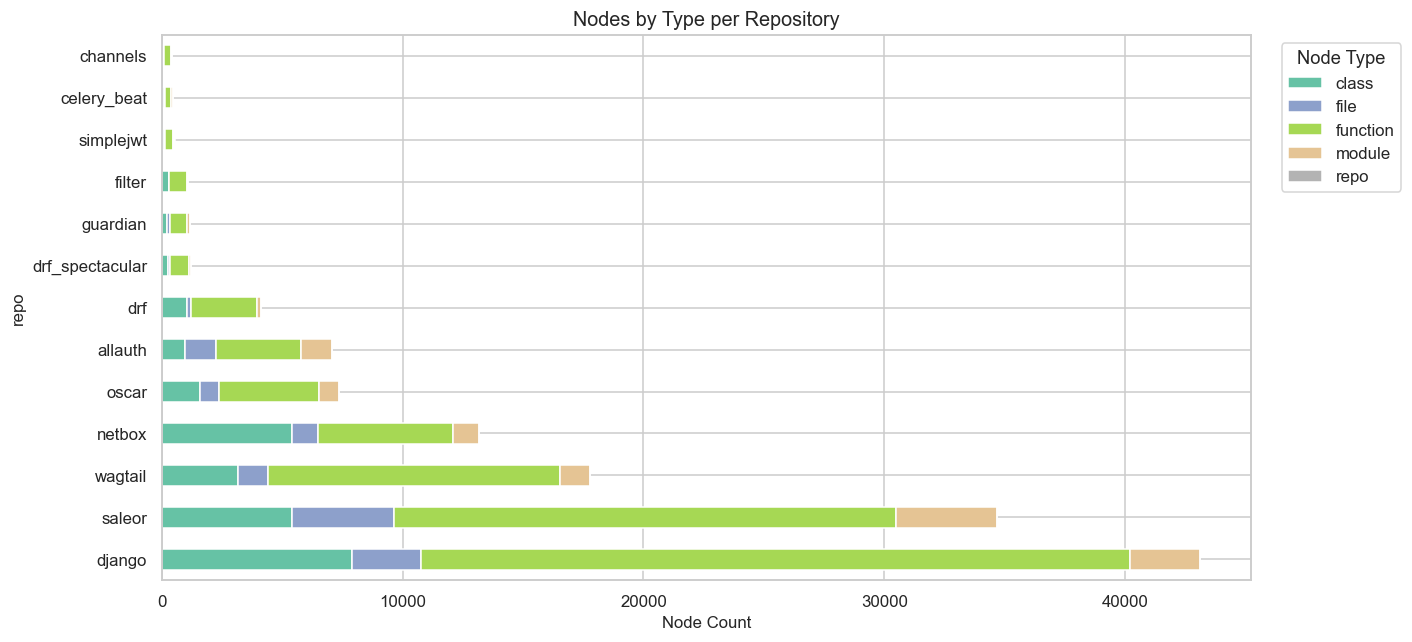


Cross-repo edges: 24,650 / 279,733 = 8.8%


In [15]:
# ── Cell 3: Per-Repo Breakdown ────────────────────────────────

# Nodes by type per repo (pivot table)
repo_type_counts = (
    nodes_df.groupby(["repo", "type"]).size().unstack(fill_value=0)
)
repo_type_counts["total"] = repo_type_counts.sum(axis=1)
repo_type_counts = repo_type_counts.sort_values("total", ascending=False)

# LOC per repo (sum of function loc where available)
func_loc = (
    nodes_df[nodes_df["type"] == "function"]
    .groupby("repo")["loc"]
    .sum()
    .rename("total_func_loc")
)

# Cross-repo edges per repo (as source)
cross_repo_out = (
    edges_df[edges_df["is_cross_repo"]]
    .groupby("source_repo").size()
    .rename("cross_repo_edges_out")
)
cross_repo_in = (
    edges_df[edges_df["is_cross_repo"]]
    .groupby("target_repo").size()
    .rename("cross_repo_edges_in")
)
total_edges_out = edges_df.groupby("source_repo").size().rename("total_edges_out")

# Build summary table
summary = repo_type_counts.join(func_loc).join(cross_repo_out).join(cross_repo_in).join(total_edges_out)
summary["cross_repo_ratio_out"] = (summary["cross_repo_edges_out"].fillna(0) / summary["total_edges_out"]).fillna(0)
summary = summary.fillna(0)

display(summary.style.format({
    "total_func_loc": "{:,.0f}",
    "cross_repo_edges_out": "{:,.0f}",
    "cross_repo_edges_in": "{:,.0f}",
    "total_edges_out": "{:,.0f}",
    "cross_repo_ratio_out": "{:.1%}",
}).set_caption("Per-Repo Summary"))

# Stacked bar chart of node types by repo
plot_cols = [c for c in repo_type_counts.columns if c != "total"]
repo_type_counts[plot_cols].plot.barh(stacked=True, figsize=(13, 6), colormap="Set2")
plt.title("Nodes by Type per Repository")
plt.xlabel("Node Count")
plt.legend(title="Node Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Cross-repo edge stats
total_cross = edges_df["is_cross_repo"].sum()
total_all = len(edges_df)
print(f"\nCross-repo edges: {total_cross:,} / {total_all:,} = {total_cross/total_all:.1%}")

## 4 — Degree Distributions & Graph Topology

Compute in-degree and out-degree from edges. Explore overall and per-node-type distributions, identify hubs and leaf nodes.

── Overall Degree Statistics ──
  computed_in_degree: mean=2.1, median=1, max=6489, p95=4, zeros=13
  computed_out_degree: mean=2.1, median=1, max=4207, p95=7, zeros=44,948
  computed_total_degree: mean=4.2, median=2, max=6490, p95=11, zeros=0


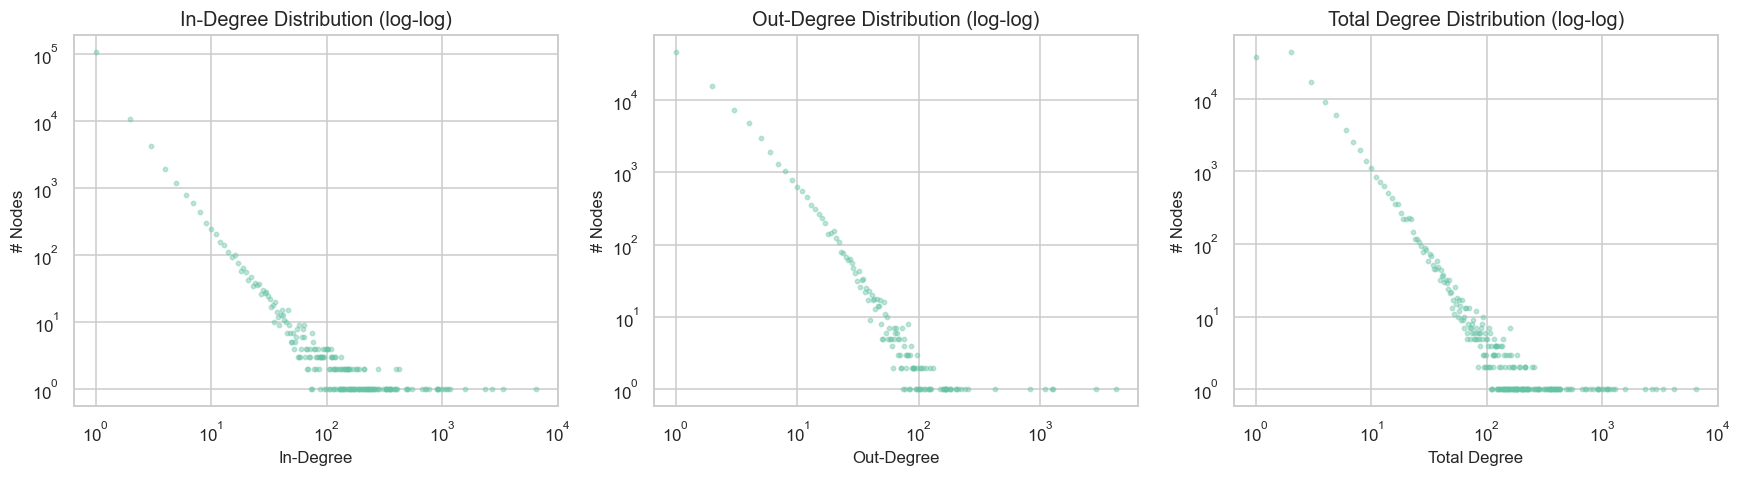

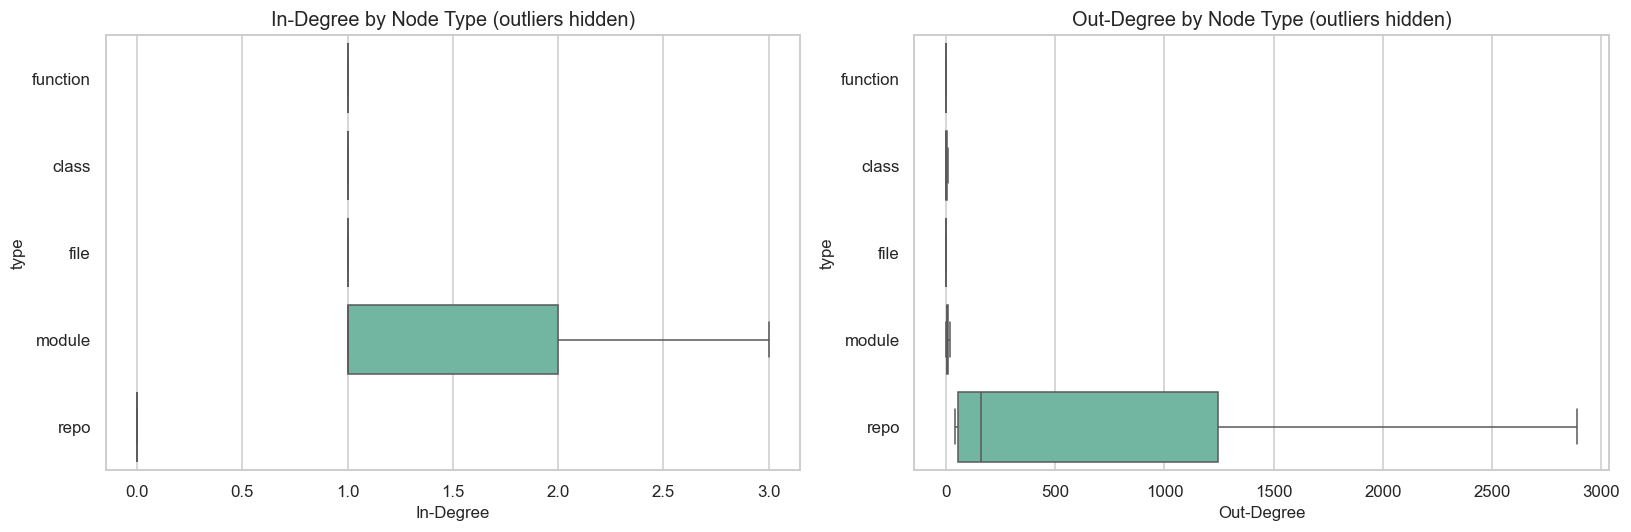


── Top 10 Nodes by Out-Degree (excl. repo) ──


,id,type,repo,computed_out_degree,computed_in_degree
0,mod::netbox::netbox.dcim.views,module,netbox,421,2
1,class::django::tests.schema.tests::SchemaTests,class,django,253,1
2,mod::saleor::saleor.graphql.webhook.subscription_types,module,saleor,239,9
3,mod::wagtail::wagtail.test.testapp.models,module,wagtail,224,125
4,class::saleor::saleor.plugins.manager::PluginsManager,class,saleor,209,1
5,class::saleor::saleor.plugins.webhook.plugin::WebhookPlugin,class,saleor,204,1
6,mod::saleor::saleor.graphql.meta.tests.test_meta_queries,module,saleor,201,1
7,mod::drf_spectacular::tests.test_regressions,module,drf_spectacular,183,1
8,mod::saleor::saleor.webhook.tests.fixtures.subscription_webhooks,module,saleor,182,2
9,mod::saleor::saleor.plugins.avatax.tests.test_avatax,module,saleor,181,1



── Top 10 Nodes by In-Degree (excl. repo) ──


,id,type,repo,computed_in_degree,computed_out_degree
0,func::saleor::saleor.graphql.tests.utils::get_graphql_content,function,saleor,6489,1
1,mod::django::django.db,module,django,3350,6
2,mod::django::django.db.models,module,django,2684,22
3,mod::django::django.db.migrations,module,django,2358,2
4,mod::django::django.test,module,django,1576,3
5,func::saleor::saleor.plugins.manager::get_plugins_manager,function,saleor,1169,3
6,func::saleor::saleor.graphql.core.utils::to_global_id_or_none,function,saleor,1113,0
7,mod::django::django.core.exceptions,module,django,1071,26
8,func::django::django.utils.timezone::now,function,django,1031,0
9,mod::django::django.conf,module,django,976,10



Isolated nodes (total degree 0)  : 0
Source-only nodes (in=0, out>0)  : 13
Sink nodes (out=0, in>0)         : 44,948


In [16]:

# ── Cell 4: Degree Distributions & Graph Topology ────────────

# Compute degrees from edges
in_deg = edges_df["target"].value_counts().rename("computed_in_degree")
out_deg = edges_df["source"].value_counts().rename("computed_out_degree")

nodes_df = nodes_df.join(in_deg, on="id").join(out_deg, on="id")
nodes_df["computed_in_degree"] = nodes_df["computed_in_degree"].fillna(0).astype(int)
nodes_df["computed_out_degree"] = nodes_df["computed_out_degree"].fillna(0).astype(int)
nodes_df["computed_total_degree"] = nodes_df["computed_in_degree"] + nodes_df["computed_out_degree"]

# Overall degree stats
print("── Overall Degree Statistics ──")
for col in ["computed_in_degree", "computed_out_degree", "computed_total_degree"]:
    s = nodes_df[col]
    print(f"  {col}: mean={s.mean():.1f}, median={s.median():.0f}, "
          f"max={s.max()}, p95={s.quantile(0.95):.0f}, zeros={( s == 0).sum():,}")

# Log-log degree distribution (power-law check)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(axes,
    ["computed_in_degree", "computed_out_degree", "computed_total_degree"],
    ["In-Degree", "Out-Degree", "Total Degree"]):
    vals = nodes_df[col]
    vals_pos = vals[vals > 0]
    counts = vals_pos.value_counts().sort_index()
    ax.scatter(counts.index, counts.values, alpha=0.4, s=8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(title)
    ax.set_ylabel("# Nodes")
    ax.set_title(f"{title} Distribution (log-log)")
plt.tight_layout()
plt.show()

# Per-node-type degree distributions (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
node_types_order = nodes_df["type"].value_counts().index.tolist()

sns.boxplot(data=nodes_df, y="type", x="computed_in_degree", order=node_types_order,
            ax=axes[0], showfliers=False)
axes[0].set_title("In-Degree by Node Type (outliers hidden)")
axes[0].set_xlabel("In-Degree")

sns.boxplot(data=nodes_df, y="type", x="computed_out_degree", order=node_types_order,
            ax=axes[1], showfliers=False)
axes[1].set_title("Out-Degree by Node Type (outliers hidden)")
axes[1].set_xlabel("Out-Degree")
plt.tight_layout()
plt.show()

# Top-10 nodes by out-degree (excluding repo nodes)
print("\n── Top 10 Nodes by Out-Degree (excl. repo) ──")
non_repo = nodes_df[nodes_df["type"] != "repo"]
top_hubs = non_repo.nlargest(10, "computed_out_degree")[["id", "type", "repo", "computed_out_degree", "computed_in_degree"]]
display(top_hubs.reset_index(drop=True))

# Top-10 nodes by in-degree (excluding repo nodes)
print("\n── Top 10 Nodes by In-Degree (excl. repo) ──")
top_auth = non_repo.nlargest(10, "computed_in_degree")[["id", "type", "repo", "computed_in_degree", "computed_out_degree"]]
display(top_auth.reset_index(drop=True))

# Leaf nodes (zero degree)
isolates = nodes_df[nodes_df["computed_total_degree"] == 0]
leaves = nodes_df[(nodes_df["computed_in_degree"] == 0) & (nodes_df["computed_out_degree"] > 0)]
sinks = nodes_df[(nodes_df["computed_out_degree"] == 0) & (nodes_df["computed_in_degree"] > 0)]
print(f"\nIsolated nodes (total degree 0)  : {len(isolates):,}")
print(f"Source-only nodes (in=0, out>0)  : {len(leaves):,}")
print(f"Sink nodes (out=0, in>0)         : {len(sinks):,}")


## 5 — Cross-Repo Connectivity

Analyze how the 13 repositories connect to each other. Build a repo-to-repo adjacency matrix and break it down by semantic edge type (IMPORTS_MODULE, INHERITS, CALLS).

Cross-repo edges: 24,650 / 279,733 (8.8%)

Breakdown by edge type:
type
IMPORTS_MODULE    17557
CALLS              6498
INHERITS            595


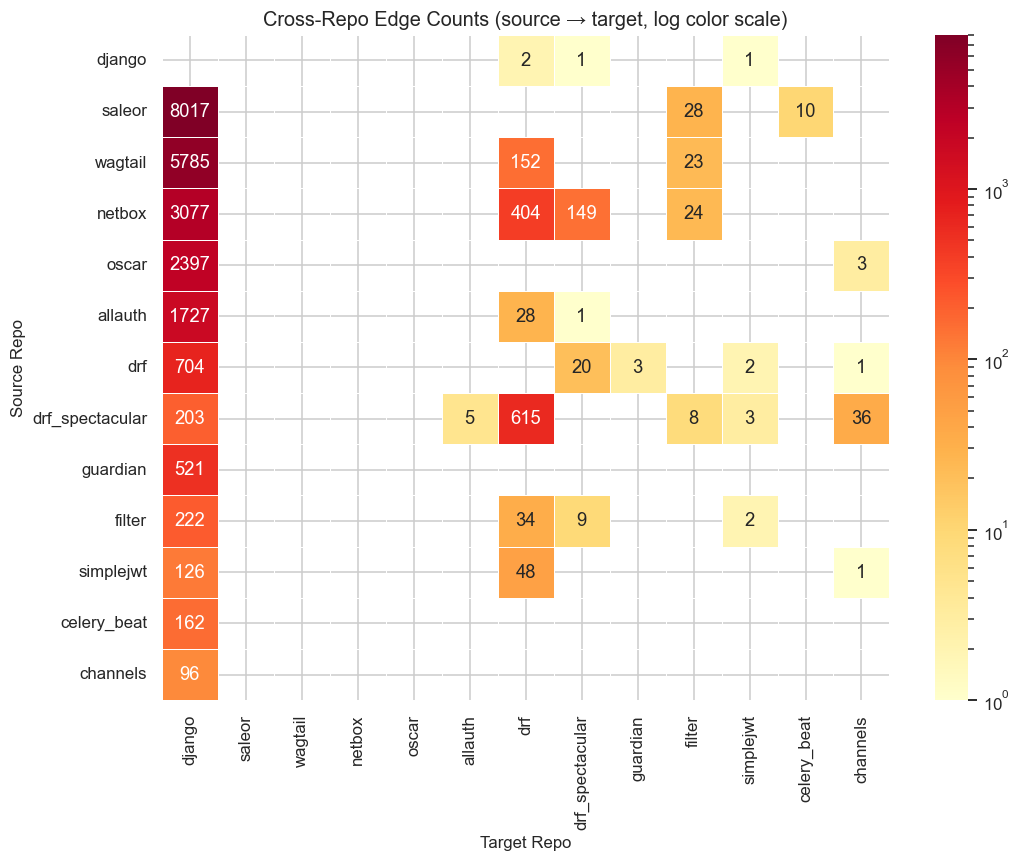

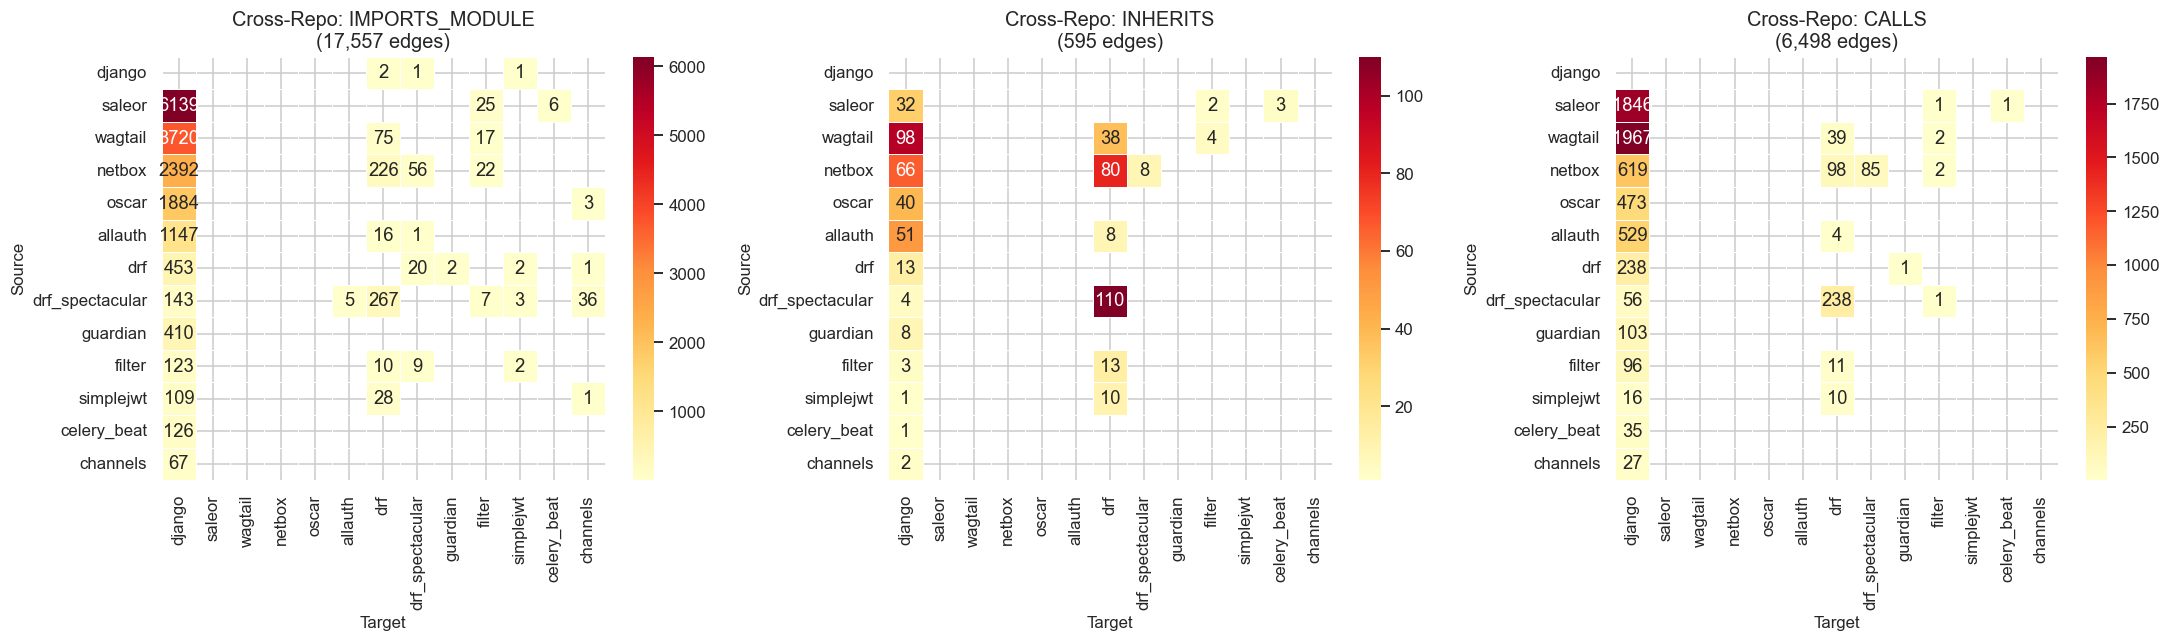

/var/folders/q4/_1_vts6n2vg5rvqrn52fvfd00000gn/T/ipykernel_67029/1318801891.py:77: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/alejandromarchini/Documents/MSAAI/capstone/source-code-RGAT/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


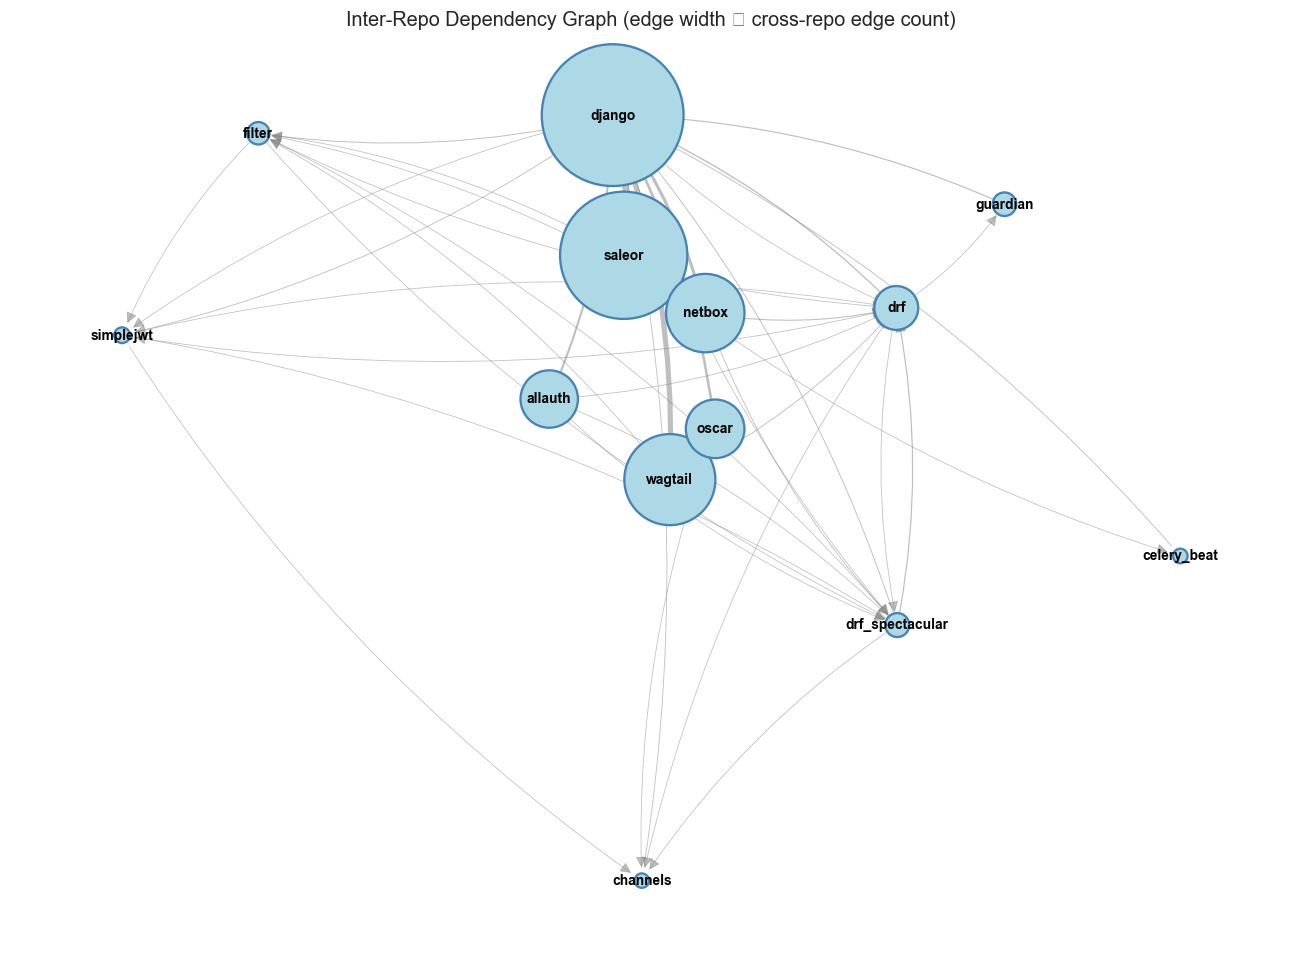


── Top 15 most-targeted nodes in cross-repo edges ──
  2,573  [  module]  mod::django::django.db
  2,154  [  module]  mod::django::django.db.migrations
  2,037  [  module]  mod::django::django.db.models
    941  [function]  func::django::django.utils.timezone::now
    795  [  module]  mod::django::django.test
    759  [function]  func::django::django.core.exceptions::ValidationError.__init__
    738  [  module]  mod::django::django.conf
    717  [  module]  mod::django::django.core.exceptions
    705  [  module]  mod::django::django.urls
    702  [  module]  mod::django::django.utils.translation
    402  [  module]  mod::django::django.utils.timezone
    388  [  module]  mod::django::django.db.models.deletion
    361  [  module]  mod::django::django.utils
    321  [  module]  mod::django::django
    280  [function]  func::django::django.utils.translation::gettext


In [17]:
# ── Cell 5: Cross-Repo Connectivity ──────────────────────────

cross_edges = edges_df[edges_df["is_cross_repo"]].copy()
print(f"Cross-repo edges: {len(cross_edges):,} / {len(edges_df):,} "
      f"({len(cross_edges)/len(edges_df):.1%})")
print(f"\nBreakdown by edge type:")
print(cross_edges["type"].value_counts().to_string())

# ── Repo × Repo heatmap (all cross-repo edges) ──
repos_ordered = nodes_df.groupby("repo").size().sort_values(ascending=False).index.tolist()
cross_matrix = (
    cross_edges.groupby(["source_repo", "target_repo"]).size()
    .unstack(fill_value=0)
    .reindex(index=repos_ordered, columns=repos_ordered, fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cross_matrix,
    annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=cross_matrix.values.max()),
    mask=(cross_matrix == 0),
)
ax.set_title("Cross-Repo Edge Counts (source → target, log color scale)")
ax.set_xlabel("Target Repo")
ax.set_ylabel("Source Repo")
plt.tight_layout()
plt.show()

# ── Per semantic edge type heatmaps ──
semantic_types = ["IMPORTS_MODULE", "INHERITS", "CALLS"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, etype in zip(axes, semantic_types):
    sub = cross_edges[cross_edges["type"] == etype]
    mat = (
        sub.groupby(["source_repo", "target_repo"]).size()
        .unstack(fill_value=0)
        .reindex(index=repos_ordered, columns=repos_ordered, fill_value=0)
    )
    sns.heatmap(
        mat, annot=True, fmt="d", cmap="YlOrRd",
        linewidths=0.5, ax=ax,
        mask=(mat == 0),
    )
    ax.set_title(f"Cross-Repo: {etype}\n({sub.shape[0]:,} edges)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")
plt.tight_layout()
plt.show()

# ── NetworkX inter-repo graph visualization ──
G_repo = nx.DiGraph()
for _, row in cross_matrix.iterrows():
    src = row.name
    for tgt, cnt in row.items():
        if cnt > 0:
            G_repo.add_edge(src, tgt, weight=cnt)

# Node sizes proportional to total nodes
repo_sizes = nodes_df.groupby("repo").size()
node_sizes = [repo_sizes.get(r, 100) / 5 for r in G_repo.nodes()]
edge_weights = [G_repo[u][v]["weight"] for u, v in G_repo.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [0.5 + 4 * w / max_w for w in edge_weights]

fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(G_repo, k=2.5, seed=42, weight="weight")
nx.draw_networkx_nodes(G_repo, pos, node_size=node_sizes, node_color="lightblue",
                       edgecolors="steelblue", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G_repo, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G_repo, pos, width=edge_widths, alpha=0.5,
                       edge_color="gray", arrows=True, arrowsize=15,
                       connectionstyle="arc3,rad=0.1", ax=ax)
ax.set_title("Inter-Repo Dependency Graph (edge width ∝ cross-repo edge count)")
ax.axis("off")
plt.tight_layout()
plt.show()

# Top cross-repo target nodes
print("\n── Top 15 most-targeted nodes in cross-repo edges ──")
top_targets = cross_edges["target"].value_counts().head(15)
for node_id, cnt in top_targets.items():
    ntype = nodes_df.loc[nodes_df["id"] == node_id, "type"].iloc[0]
    print(f"  {cnt:>5,}  [{ntype:>8s}]  {node_id}")

## 6 — Feature Distributions by Node Type

Histograms and boxplots for key numeric features of each node type (functions, classes, modules, files, repos).

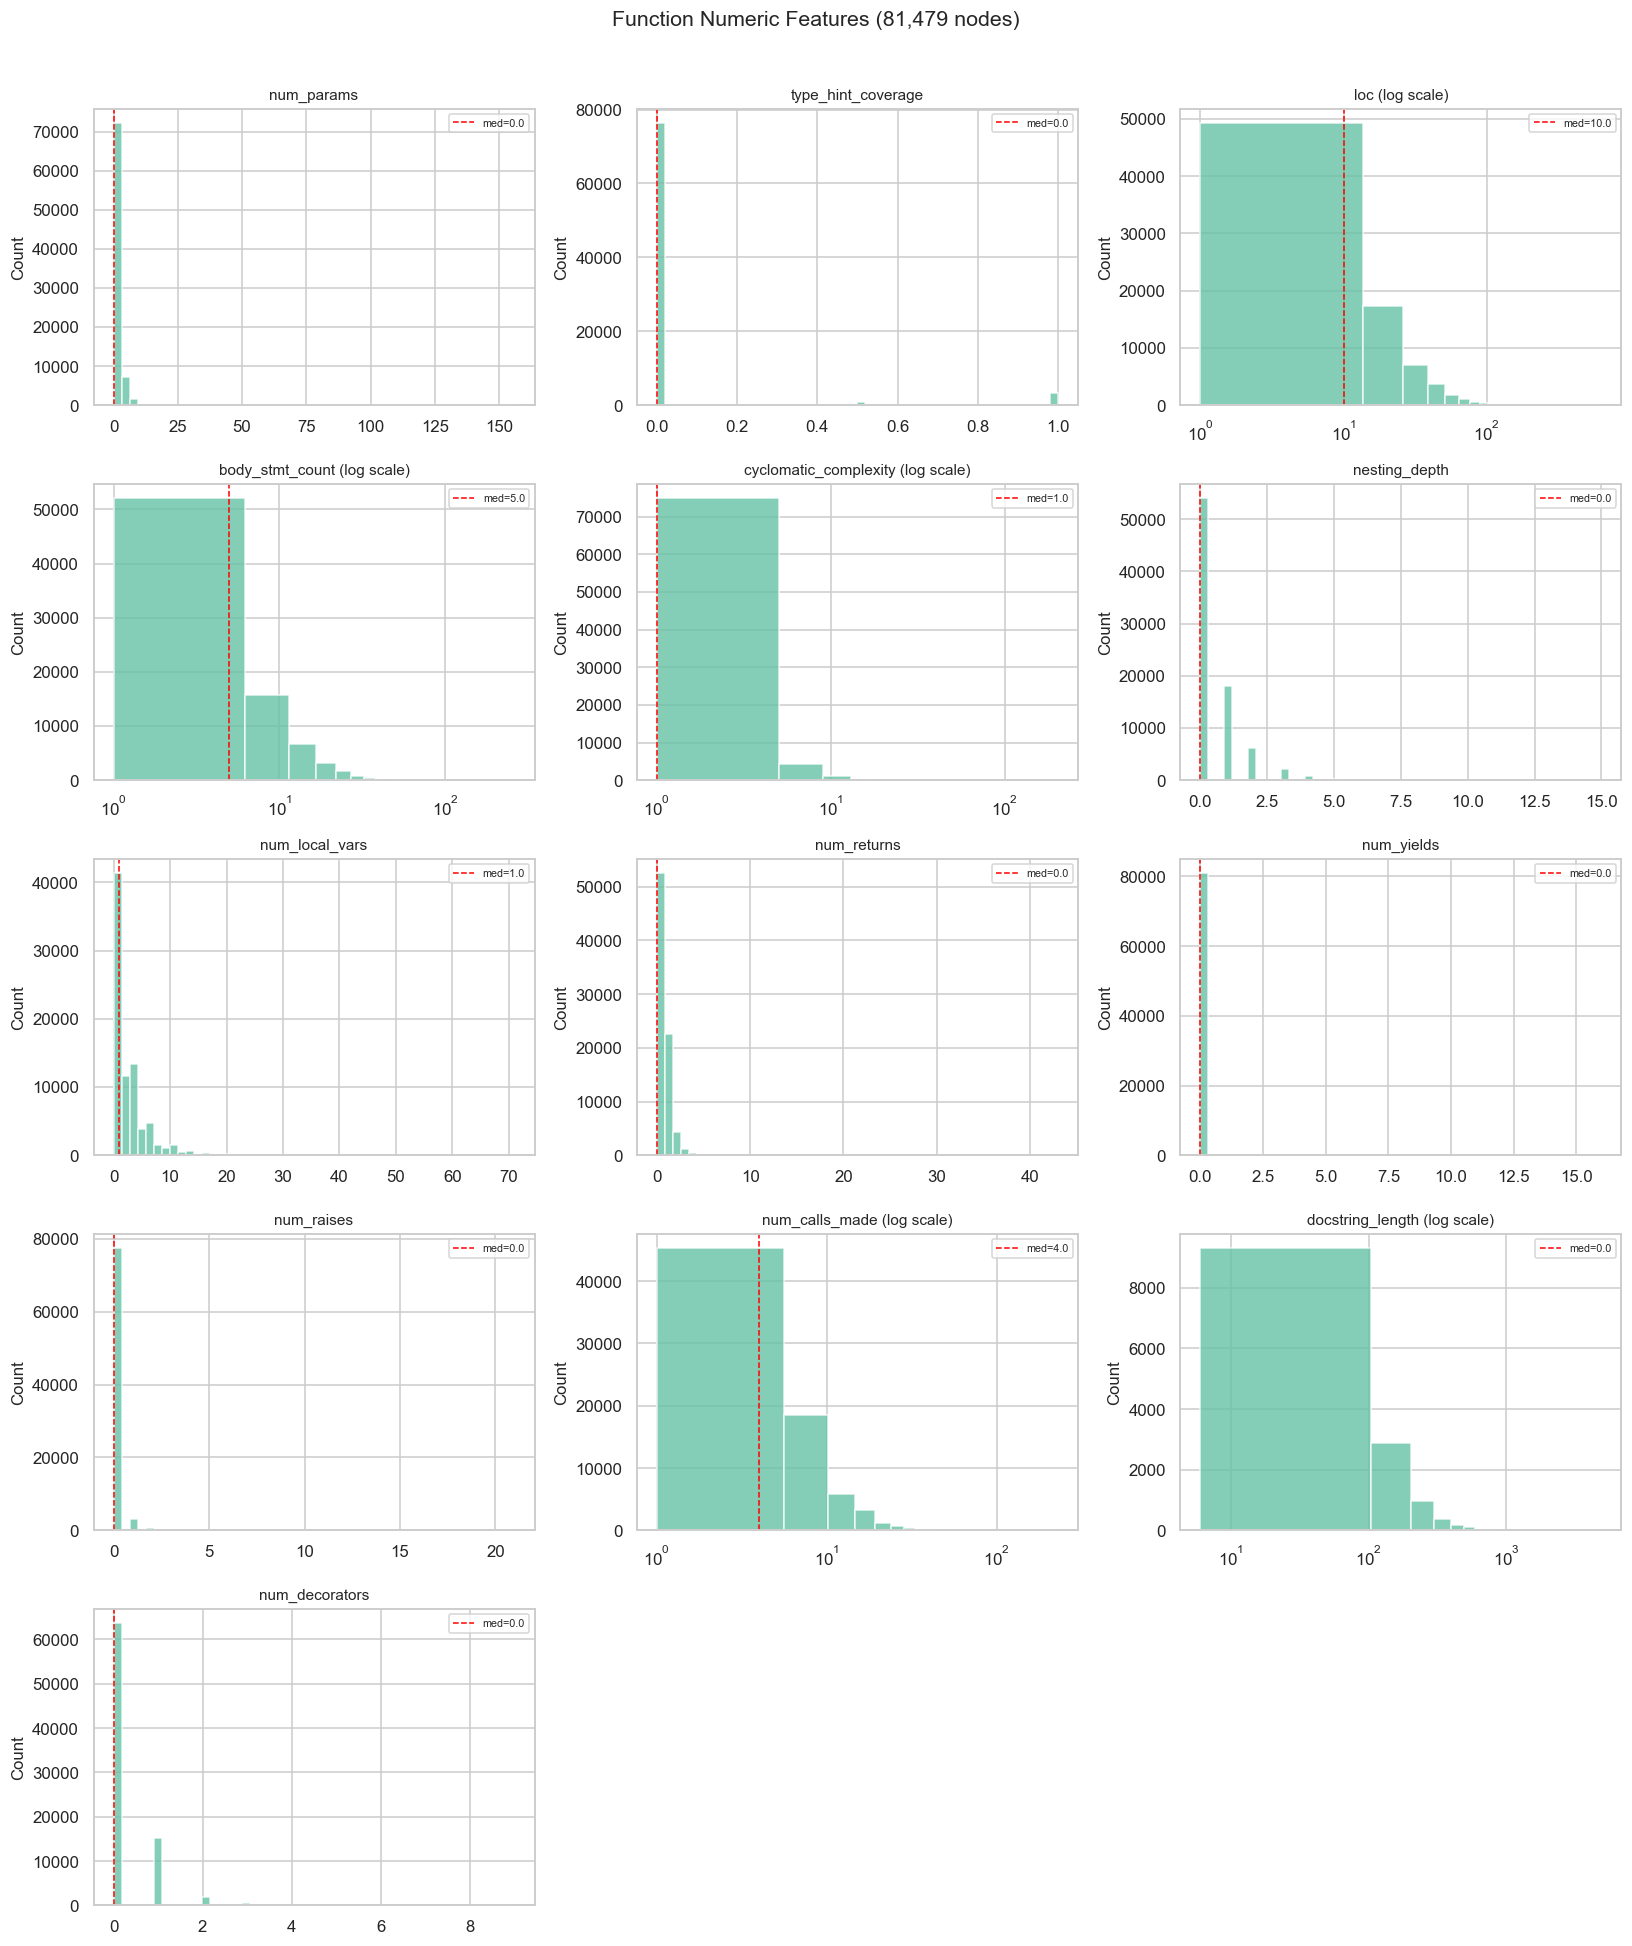

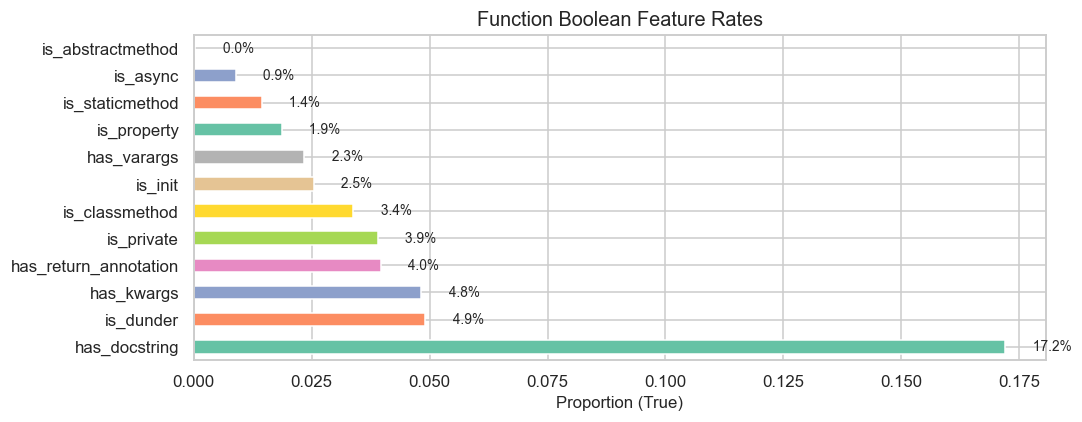

In [18]:
# ── Cell 6: Feature Distributions by Node Type ───────────────

# Helper: plot a grid of histograms for a slice of nodes
def plot_feature_histograms(df, features, title, ncols=3, log_features=None):
    """Plot histograms for selected numeric features of a DataFrame slice."""
    log_features = log_features or set()
    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    for i, feat in enumerate(features):
        ax = axes[i]
        data = df[feat].dropna().astype(float)  # cast bool→float for histogram compat
        if len(data) == 0:
            ax.set_visible(False)
            continue
        use_log = feat in log_features and (data > 0).any()
        if use_log:
            data_plot = data[data > 0]
            ax.hist(data_plot, bins=50, edgecolor="white", alpha=0.8)
            ax.set_xscale("log")
            ax.set_title(f"{feat} (log scale)", fontsize=10)
        else:
            ax.hist(data, bins=50, edgecolor="white", alpha=0.8)
            ax.set_title(feat, fontsize=10)
        ax.set_ylabel("Count")
        ax.axvline(data.median(), color="red", ls="--", lw=1, label=f"med={data.median():.1f}")
        ax.legend(fontsize=7, loc="upper right")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# ── 6a: Function features (numeric only — booleans shown separately) ──
funcs = nodes_df[nodes_df["type"] == "function"]
func_num_features = [
    "num_params", "type_hint_coverage", "loc", "body_stmt_count",
    "cyclomatic_complexity", "nesting_depth", "num_local_vars",
    "num_returns", "num_yields", "num_raises", "num_calls_made",
    "docstring_length", "num_decorators",
]
func_log_feats = {"loc", "body_stmt_count", "docstring_length",
                  "cyclomatic_complexity", "num_calls_made"}
plot_feature_histograms(funcs, func_num_features,
    f"Function Numeric Features ({len(funcs):,} nodes)", ncols=3, log_features=func_log_feats)

# Boolean feature summary for functions
bool_feats = ["is_async", "is_staticmethod", "is_classmethod", "is_property",
              "is_abstractmethod", "is_dunder", "is_init", "is_private",
              "has_docstring", "has_return_annotation", "has_varargs", "has_kwargs"]
bool_rates = funcs[bool_feats].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
bool_rates.plot.barh(ax=ax, color=sns.color_palette("Set2", len(bool_rates)))
ax.set_xlabel("Proportion (True)")
ax.set_title("Function Boolean Feature Rates")
for i, v in enumerate(bool_rates):
    ax.text(v + 0.005, i, f" {v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

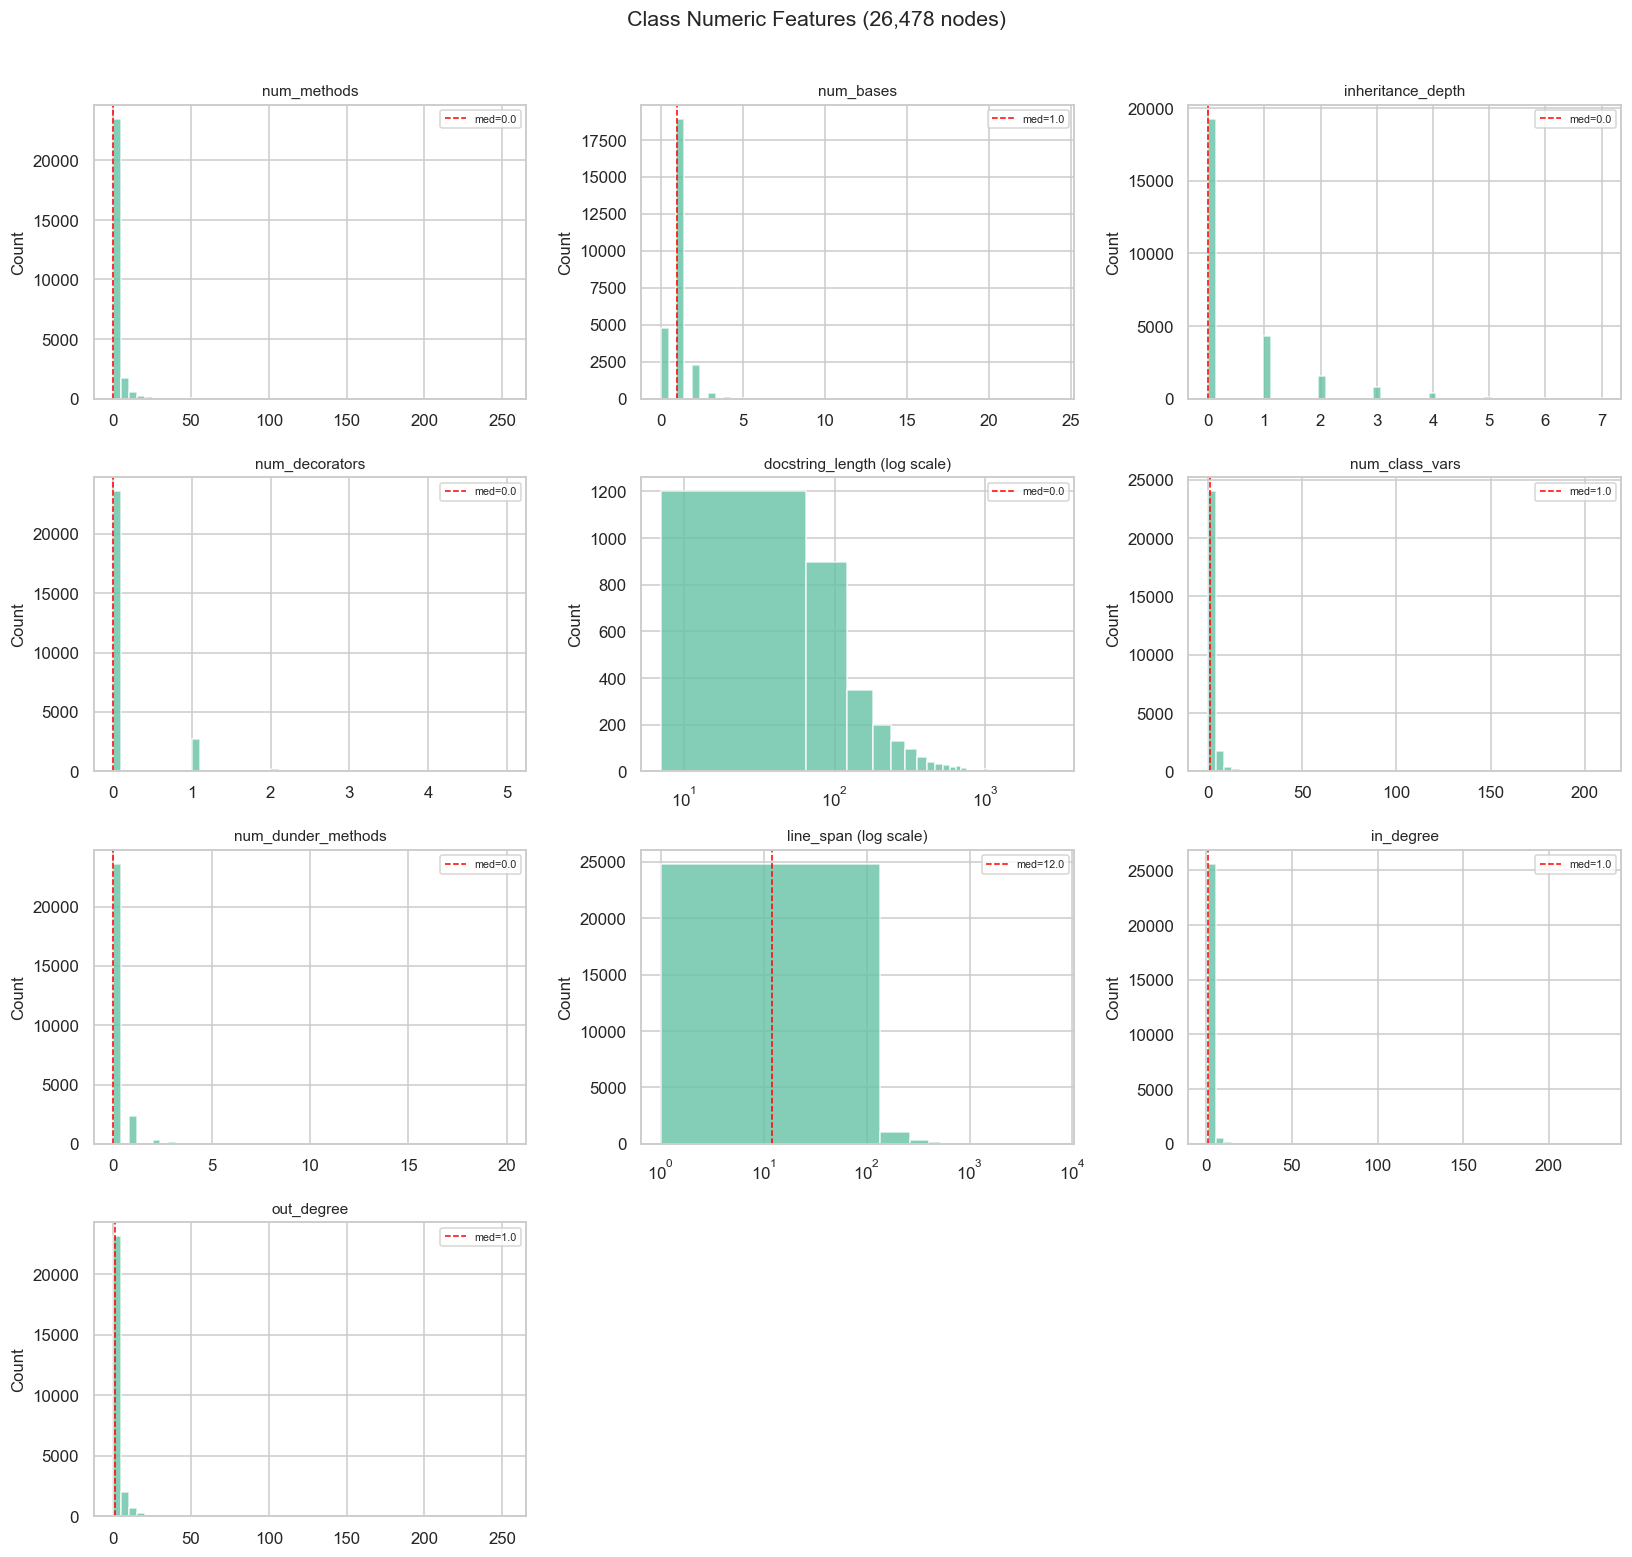

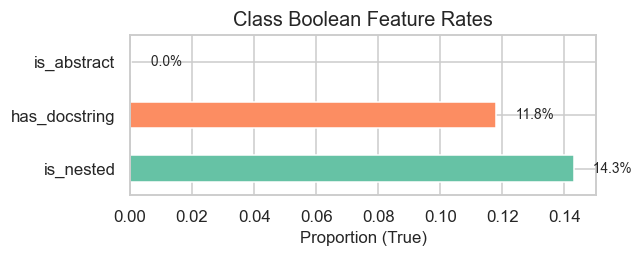

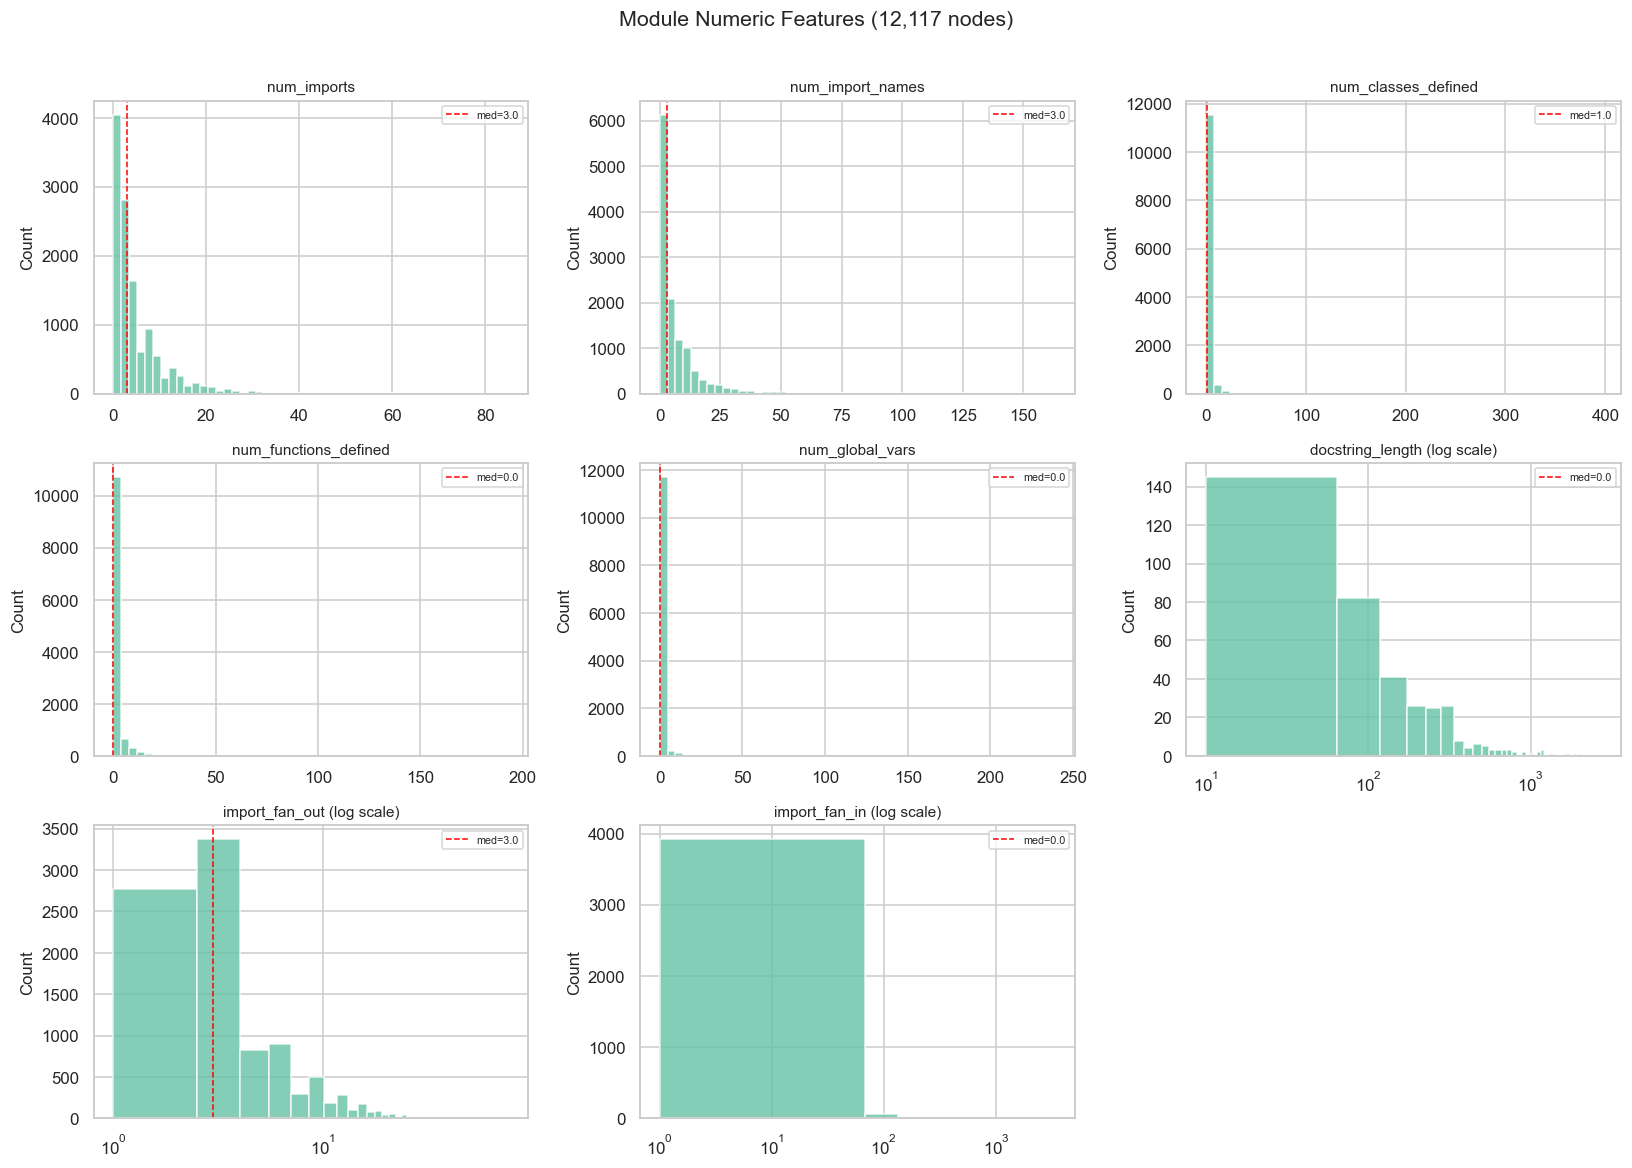

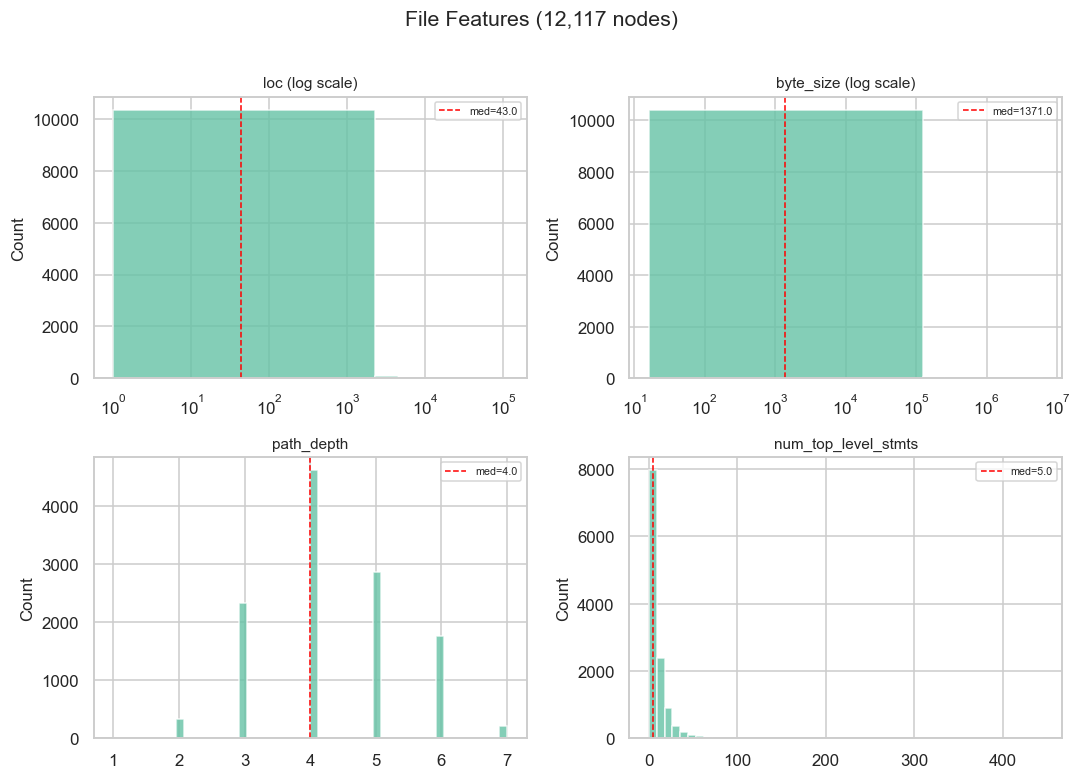

File boolean feat rates:
  is_test: 43.3%
  is_init: 16.2%

── Repo-level features (13 repos) ──


,id,num_files,num_modules,num_classes,num_functions,total_loc,num_packages
0,repo::saleor,4207.0000,4207.0000,5426.0000,20848.0000,817792.0000,1978.0000
1,repo::django,2890.0000,2890.0000,7889.0000,29418.0000,505001.0000,1978.0000
2,repo::netbox,1090.0000,1090.0000,5390.0000,5604.0000,315952.0000,1978.0000
3,repo::wagtail,1247.0000,1247.0000,3184.0000,12085.0000,240276.0000,1978.0000
4,repo::oscar,823.0000,823.0000,1571.0000,4146.0000,71016.0000,1978.0000
5,repo::allauth,1275.0000,1275.0000,967.0000,3548.0000,60734.0000,1978.0000
6,repo::drf,158.0000,158.0000,1065.0000,2741.0000,43456.0000,1978.0000
7,repo::drf_spectacular,97.0000,97.0000,252.0000,783.0000,19180.0000,1978.0000
8,repo::guardian,131.0000,131.0000,215.0000,715.0000,14300.0000,1978.0000
9,repo::filter,39.0000,39.0000,282.0000,717.0000,11267.0000,1978.0000


In [19]:
# ── Cell 6b: Class, Module, File, Repo features ──────────────

# ── Classes ──
classes = nodes_df[nodes_df["type"] == "class"]
class_features = [
    "num_methods", "num_bases", "inheritance_depth", "num_decorators",
    "docstring_length", "num_class_vars", "num_dunder_methods", "line_span",
    "in_degree", "out_degree",
]
class_log = {"docstring_length", "line_span"}
plot_feature_histograms(classes, class_features,
    f"Class Numeric Features ({len(classes):,} nodes)", ncols=3, log_features=class_log)

class_bool = ["has_docstring", "is_abstract", "is_nested"]
class_bool_rates = classes[class_bool].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 2.5))
class_bool_rates.plot.barh(ax=ax, color=sns.color_palette("Set2", len(class_bool_rates)))
ax.set_xlabel("Proportion (True)")
ax.set_title("Class Boolean Feature Rates")
for i, v in enumerate(class_bool_rates):
    ax.text(v + 0.005, i, f" {v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# ── Modules ──
modules = nodes_df[nodes_df["type"] == "module"]
mod_features = [
    "num_imports", "num_import_names", "num_classes_defined",
    "num_functions_defined", "num_global_vars", "docstring_length",
    "import_fan_out", "import_fan_in",
]
mod_log = {"docstring_length", "import_fan_in", "import_fan_out"}
plot_feature_histograms(modules, mod_features,
    f"Module Numeric Features ({len(modules):,} nodes)", ncols=3, log_features=mod_log)

# ── Files ──
files = nodes_df[nodes_df["type"] == "file"]
file_features = ["loc", "byte_size", "path_depth", "num_top_level_stmts"]
file_log = {"loc", "byte_size"}
plot_feature_histograms(files, file_features,
    f"File Features ({len(files):,} nodes)", ncols=2, log_features=file_log)

file_bool = ["is_init", "is_test"]
file_bool_rates = files[file_bool].mean().sort_values(ascending=False)
print("File boolean feat rates:")
for feat, rate in file_bool_rates.items():
    print(f"  {feat}: {rate:.1%}")

# ── Repos (small table is more useful than histograms for 13 rows) ──
repos = nodes_df[nodes_df["type"] == "repo"]
repo_features = ["num_files", "num_modules", "num_classes", "num_functions",
                 "total_loc", "num_packages"]
print(f"\n── Repo-level features ({len(repos)} repos) ──")
display(repos[["id"] + repo_features].sort_values("total_loc", ascending=False).reset_index(drop=True))

## 7 — Graph Centrality Analysis (PageRank, HITS)

The graph builder pre-computed `pagerank`, `hub_score`, and `authority_score` on the semantic subgraph (IMPORTS_MODULE, INHERITS, CALLS edges only). Explore distributions, top nodes, and correlations with degree.

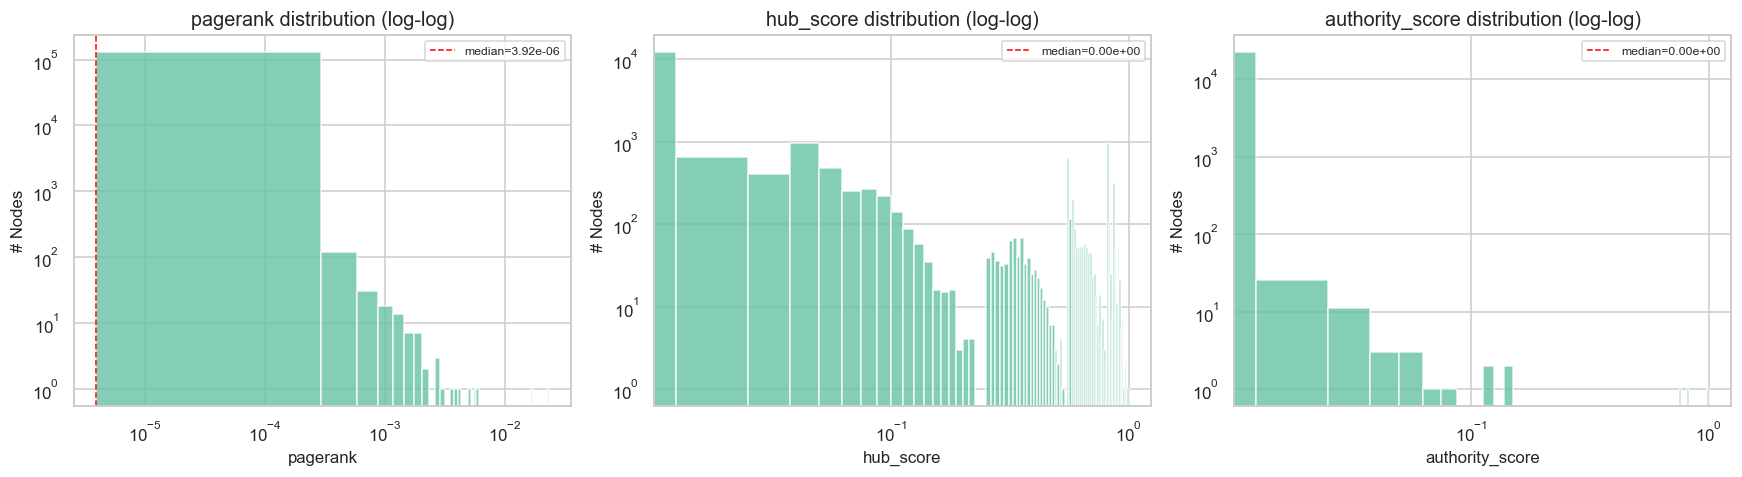


── Top 20 by pagerank ──


,id,type,repo,pagerank
0,func::django::django.core.exceptions::ValidationError.__init__,function,django,0.0230
1,func::saleor::saleor.graphql.tests.utils::get_graphql_content,function,saleor,0.0176
2,func::saleor::saleor.graphql.tests.utils::get_graphql_content_from_response,function,saleor,0.0167
3,mod::django::django.conf,module,django,0.0059
4,mod::django::django.db,module,django,0.0057
5,mod::django::django.utils.functional,module,django,0.0051
6,mod::django::django.core.exceptions,module,django,0.0040
7,mod::django::django.db.models,module,django,0.0039
8,mod::django::django.utils.hashable,module,django,0.0036
9,func::django::tests.template_tests.utils::setup,function,django,0.0029



── Top 20 by hub_score ──


,id,type,repo,hub_score
0,mod::django::tests.migrations.test_writer,module,django,1.0000
1,mod::wagtail::wagtail.models.i18n,module,wagtail,0.9720
2,mod::django::tests.migrations.test_autodetector,module,django,0.9713
3,mod::guardian::guardian.testapp.migrations.0001_initial,module,guardian,0.9572
4,mod::django::tests.migrations.test_operations,module,django,0.9479
5,mod::saleor::saleor.order.migrations.0001_initial,module,saleor,0.9451
6,mod::saleor::saleor.order.migrations.0027_auto_20180108_0814,module,saleor,0.9451
7,mod::saleor::saleor.account.migrations.0027_customerevent,module,saleor,0.9439
8,mod::saleor::saleor.csv.migrations.0001_initial,module,saleor,0.9439
9,mod::saleor::saleor.invoice.migrations.0001_initial,module,saleor,0.9439



── Top 20 by authority_score ──


,id,type,repo,authority_score
0,mod::django::django.db,module,django,1.0000
1,mod::django::django.db.models,module,django,0.8174
2,mod::django::django.db.migrations,module,django,0.7540
3,mod::django::django.db.models.deletion,module,django,0.1492
4,mod::django::django.conf,module,django,0.1427
5,mod::django::django.test,module,django,0.1234
6,mod::django::django.core.exceptions,module,django,0.1154
7,mod::django::django.utils.translation,module,django,0.0837
8,mod::django::django.utils.timezone,module,django,0.0648
9,mod::django::django.utils,module,django,0.0549


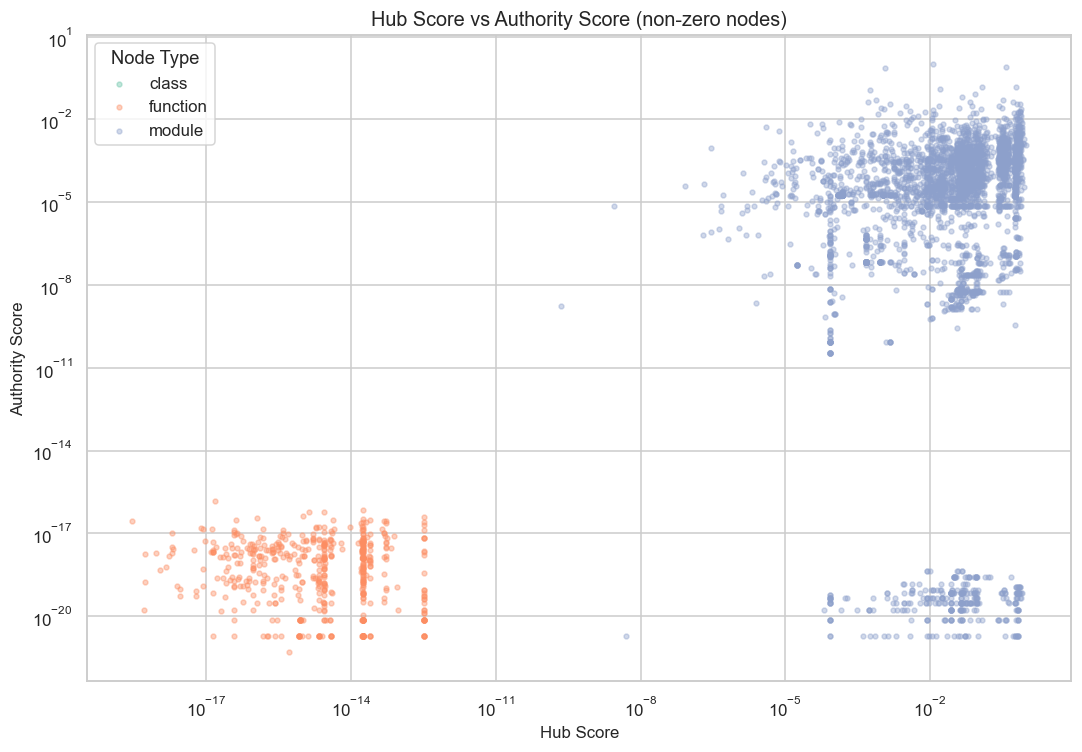

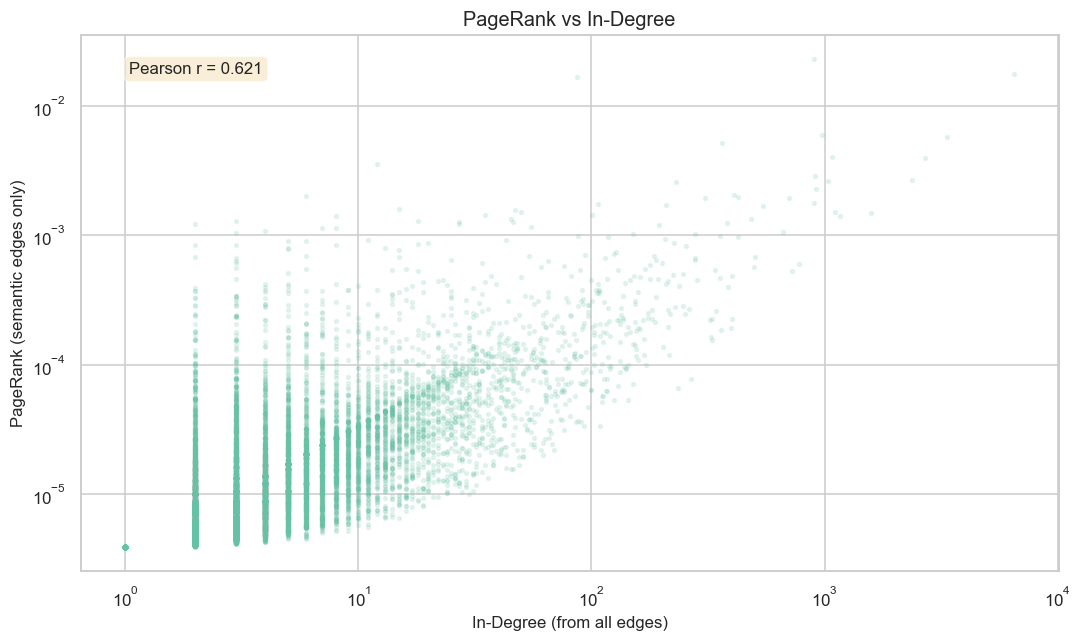

In [20]:
# ── Cell 7: Graph Centrality Analysis ─────────────────────────

centrality_cols = ["pagerank", "hub_score", "authority_score"]

# ── Distributions (log-scale histograms) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, centrality_cols):
    data = nodes_df[col].dropna()
    data_pos = data[data > 0]
    ax.hist(data_pos, bins=80, edgecolor="white", alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{col} distribution (log-log)")
    ax.set_xlabel(col)
    ax.set_ylabel("# Nodes")
    ax.axvline(data.median(), color="red", ls="--", lw=1,
               label=f"median={data.median():.2e}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Top 20 nodes by each centrality metric ──
for col in centrality_cols:
    print(f"\n── Top 20 by {col} ──")
    top = nodes_df.nlargest(20, col)[["id", "type", "repo", col]].reset_index(drop=True)
    display(top)

# ── Hub vs Authority scatter (colored by node type) ──
sample = nodes_df[nodes_df["hub_score"] + nodes_df["authority_score"] > 0].copy()
fig, ax = plt.subplots(figsize=(10, 7))
types_present = sample["type"].unique()
palette = dict(zip(types_present, sns.color_palette("Set2", len(types_present))))
for ntype in types_present:
    s = sample[sample["type"] == ntype]
    ax.scatter(s["hub_score"], s["authority_score"], alpha=0.4, s=10,
               label=ntype, color=palette[ntype])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Hub Score")
ax.set_ylabel("Authority Score")
ax.set_title("Hub Score vs Authority Score (non-zero nodes)")
ax.legend(title="Node Type")
plt.tight_layout()
plt.show()

# ── PageRank vs In-Degree scatter ──
fig, ax = plt.subplots(figsize=(10, 6))
pr_data = nodes_df[(nodes_df["pagerank"] > 0) & (nodes_df["computed_in_degree"] > 0)]
ax.scatter(pr_data["computed_in_degree"], pr_data["pagerank"], alpha=0.15, s=6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("In-Degree (from all edges)")
ax.set_ylabel("PageRank (semantic edges only)")
ax.set_title("PageRank vs In-Degree")
# Annotate correlation
corr = pr_data[["computed_in_degree", "pagerank"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"Pearson r = {corr:.3f}", transform=ax.transAxes,
        fontsize=11, va="top", bbox=dict(boxstyle="round", fc="wheat", alpha=0.5))
plt.tight_layout()
plt.show()

## 8 — Leiden Community Analysis

The graph builder ran Leiden community detection on the semantic subgraph. Nodes not in any community have `leiden_community == -1` (isolates). Explore community size distribution, cross-repo composition, and isolate characteristics.

Total nodes              : 132,204
Leiden communities found : 2,874
Isolates (community -1)  : 57,418  (43.4%)
In a community           : 74,786  (56.6%)

Community size stats: mean=26.0, median=3, max=7211, min=1


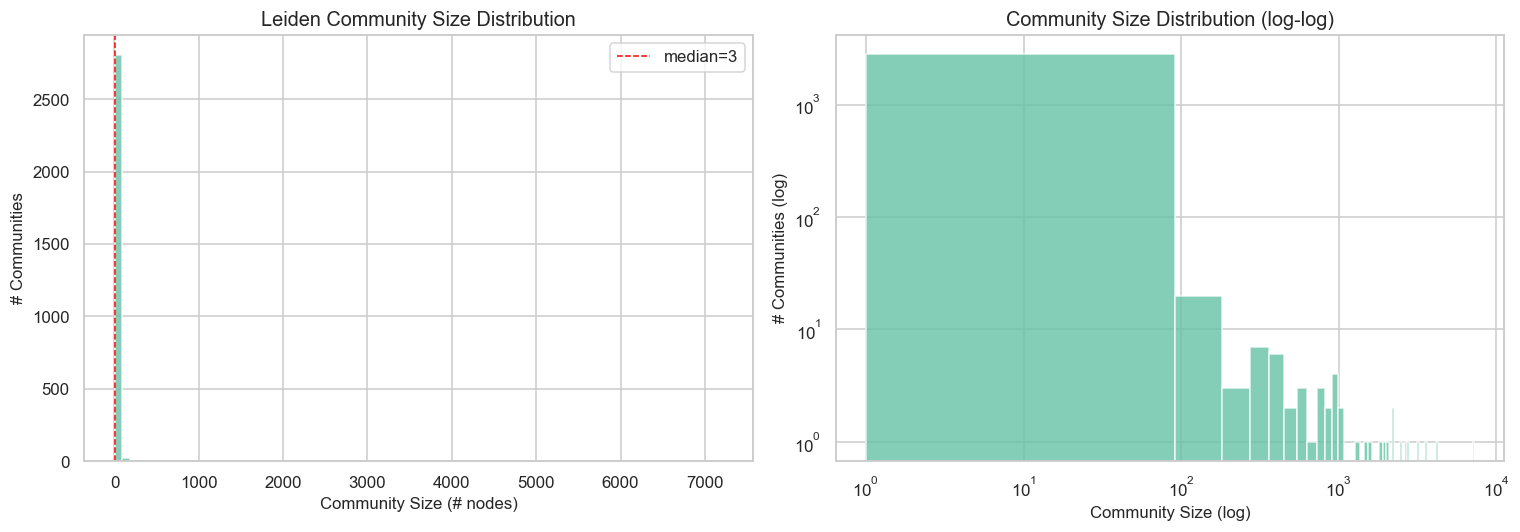


Isolate breakdown by node type:
type
function    26717
class       16777
file        12117
module       1794
repo           13

Isolate breakdown by repo:
repo
django             18793
saleor             10945
netbox              9171
wagtail             7081
oscar               4836
allauth             3188
drf                 1670
filter               445
guardian             426
drf_spectacular      274
simplejwt            240
celery_beat          189
channels             160


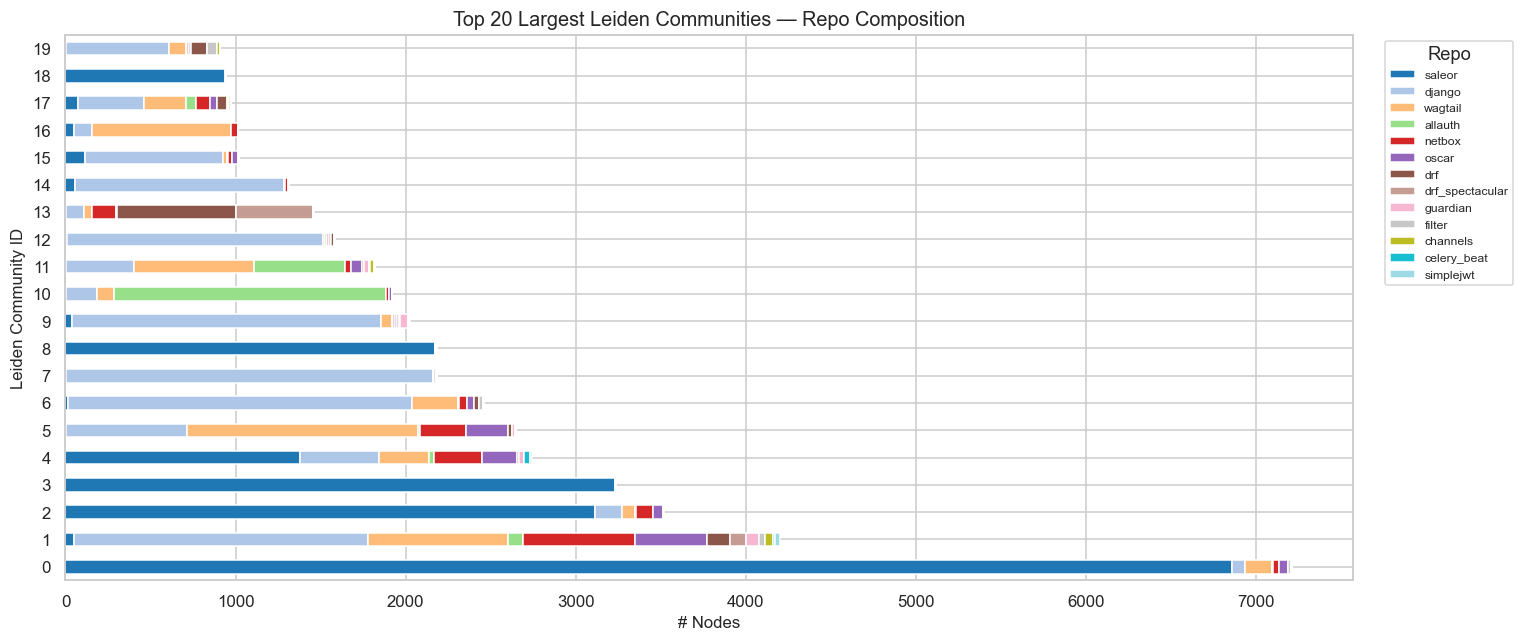


Communities spanning multiple repos: 90 / 2,874 (3.1%)
Single-repo communities           : 2,784 / 2,874 (96.9%)


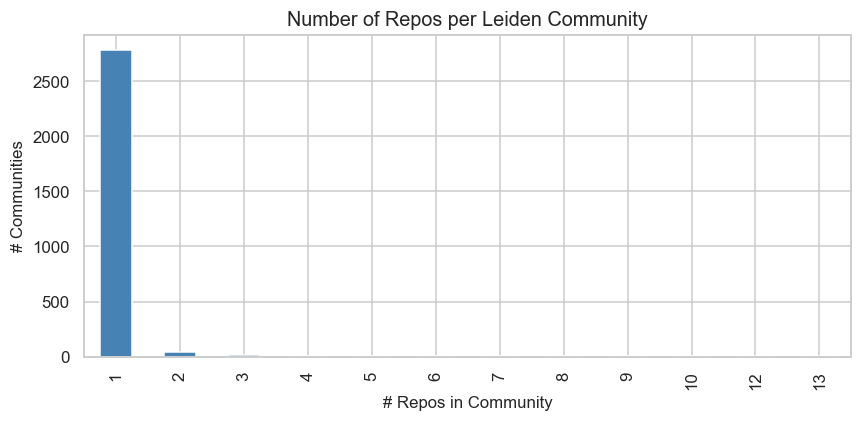

In [21]:
# ── Cell 8: Leiden Community Analysis ─────────────────────────

leiden = nodes_df["leiden_community"].copy()

n_isolates = (leiden == -1).sum()
n_communities = leiden[leiden >= 0].nunique()
total = len(leiden)

print(f"Total nodes              : {total:,}")
print(f"Leiden communities found : {n_communities:,}")
print(f"Isolates (community -1)  : {n_isolates:,}  ({n_isolates/total:.1%})")
print(f"In a community           : {total - n_isolates:,}  ({(total - n_isolates)/total:.1%})")

# ── Community size distribution ──
comm_sizes = leiden[leiden >= 0].value_counts().sort_values(ascending=False)
print(f"\nCommunity size stats: mean={comm_sizes.mean():.1f}, "
      f"median={comm_sizes.median():.0f}, max={comm_sizes.max()}, min={comm_sizes.min()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of community sizes
axes[0].hist(comm_sizes.values, bins=80, edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Community Size (# nodes)")
axes[0].set_ylabel("# Communities")
axes[0].set_title("Leiden Community Size Distribution")
axes[0].axvline(comm_sizes.median(), color="red", ls="--", lw=1,
                label=f"median={comm_sizes.median():.0f}")
axes[0].legend()

# Log-scale version
axes[1].hist(comm_sizes.values, bins=80, edgecolor="white", alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Community Size (log)")
axes[1].set_ylabel("# Communities (log)")
axes[1].set_title("Community Size Distribution (log-log)")
plt.tight_layout()
plt.show()

# ── Isolate analysis ──
isolate_df = nodes_df[leiden == -1]
print("\nIsolate breakdown by node type:")
print(isolate_df["type"].value_counts().to_string())
print("\nIsolate breakdown by repo:")
print(isolate_df.groupby("repo").size().sort_values(ascending=False).to_string())

# ── Top 20 largest communities: repo composition ──
top_comms = comm_sizes.head(20).index.tolist()
comm_repo = (
    nodes_df[nodes_df["leiden_community"].isin(top_comms)]
    .groupby(["leiden_community", "repo"]).size()
    .unstack(fill_value=0)
)
# Reorder columns by total nodes per repo
comm_repo = comm_repo[comm_repo.sum().sort_values(ascending=False).index]
comm_repo = comm_repo.loc[top_comms]  # preserve size order

fig, ax = plt.subplots(figsize=(14, 6))
comm_repo.plot.barh(stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("# Nodes")
ax.set_ylabel("Leiden Community ID")
ax.set_title("Top 20 Largest Leiden Communities — Repo Composition")
ax.legend(title="Repo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ── Cross-repo communities ──
comm_repo_full = (
    nodes_df[nodes_df["leiden_community"] >= 0]
    .groupby("leiden_community")["repo"].nunique()
)
n_multi_repo = (comm_repo_full > 1).sum()
n_single_repo = (comm_repo_full == 1).sum()
print(f"\nCommunities spanning multiple repos: {n_multi_repo:,} / {n_communities:,} "
      f"({n_multi_repo/n_communities:.1%})")
print(f"Single-repo communities           : {n_single_repo:,} / {n_communities:,} "
      f"({n_single_repo/n_communities:.1%})")

# Distribution of # repos per community
fig, ax = plt.subplots(figsize=(8, 4))
comm_repo_full.value_counts().sort_index().plot.bar(ax=ax, color="steelblue")
ax.set_xlabel("# Repos in Community")
ax.set_ylabel("# Communities")
ax.set_title("Number of Repos per Leiden Community")
plt.tight_layout()
plt.show()

## 9 — Feature Correlation Analysis

Pearson correlation matrices for the two richest node types (functions and classes). Identifies redundant feature pairs and potential multicollinearity issues for downstream ML models.


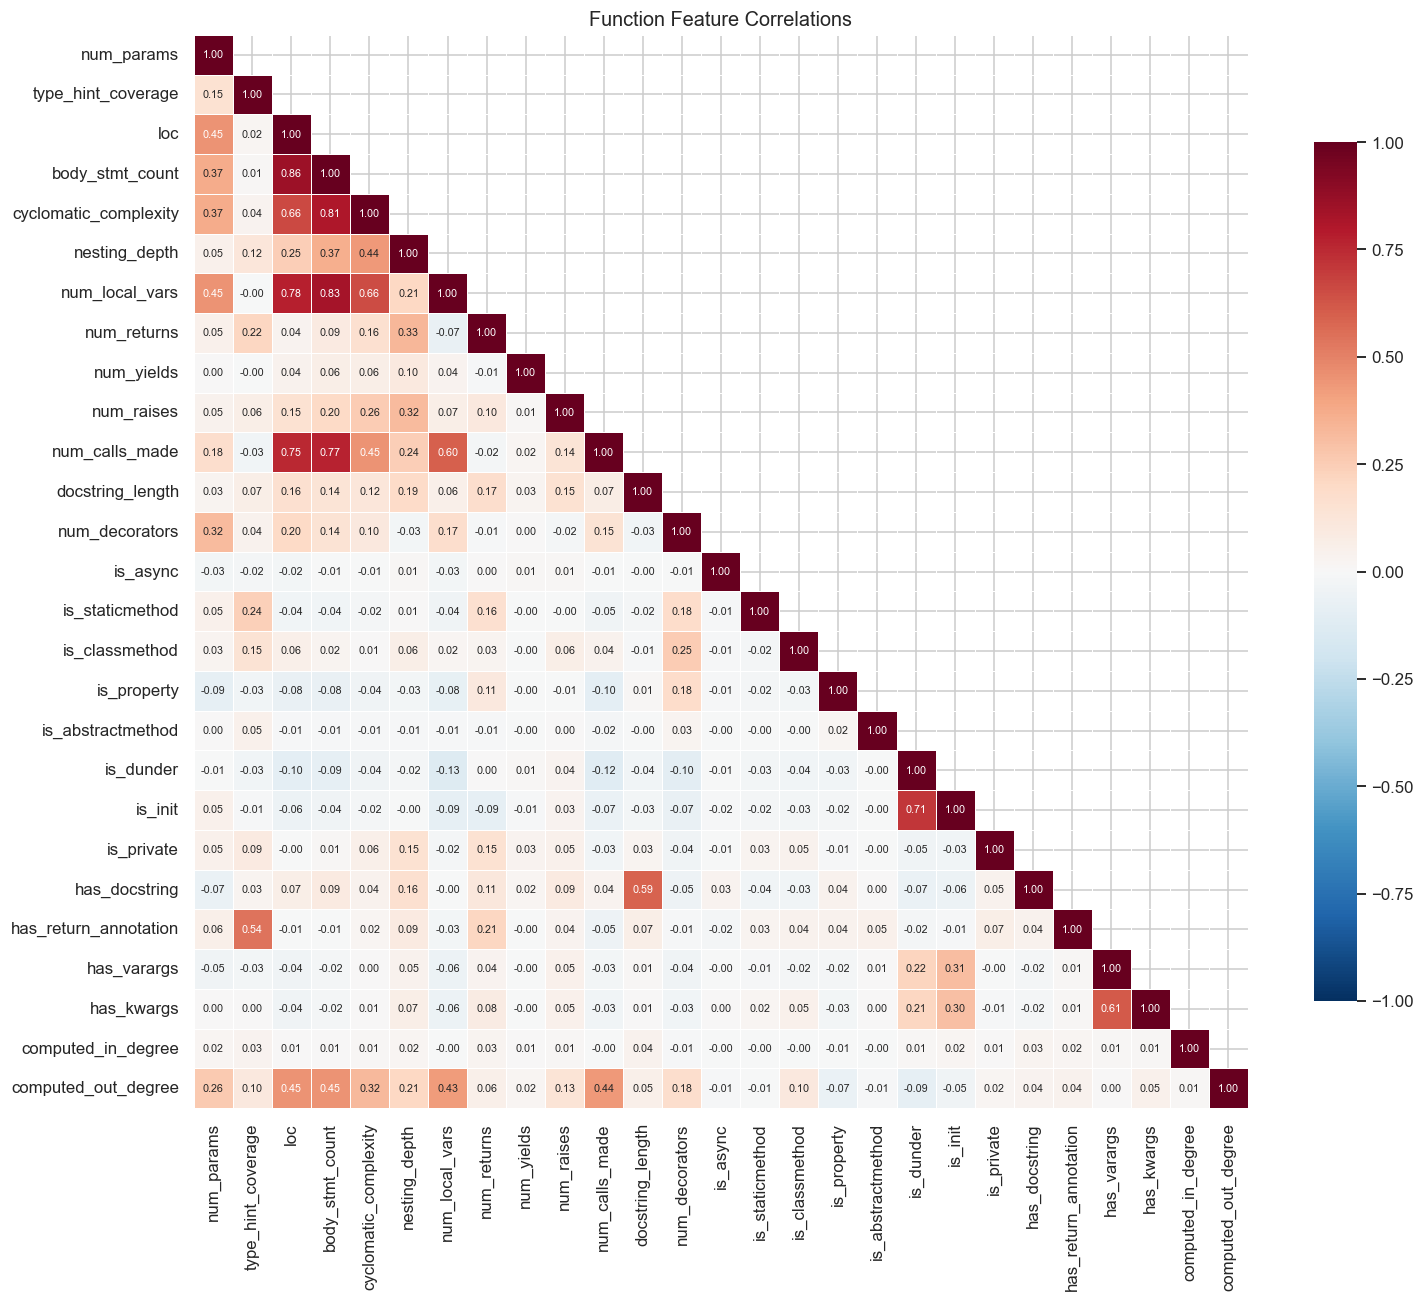

── Strong function feature pairs (|r| ≥ 0.70) ──


,feature_A,feature_B,r
0,loc,body_stmt_count,0.859
1,body_stmt_count,num_local_vars,0.831
2,body_stmt_count,cyclomatic_complexity,0.806
3,loc,num_local_vars,0.781
4,body_stmt_count,num_calls_made,0.769
5,loc,num_calls_made,0.753
6,is_dunder,is_init,0.711


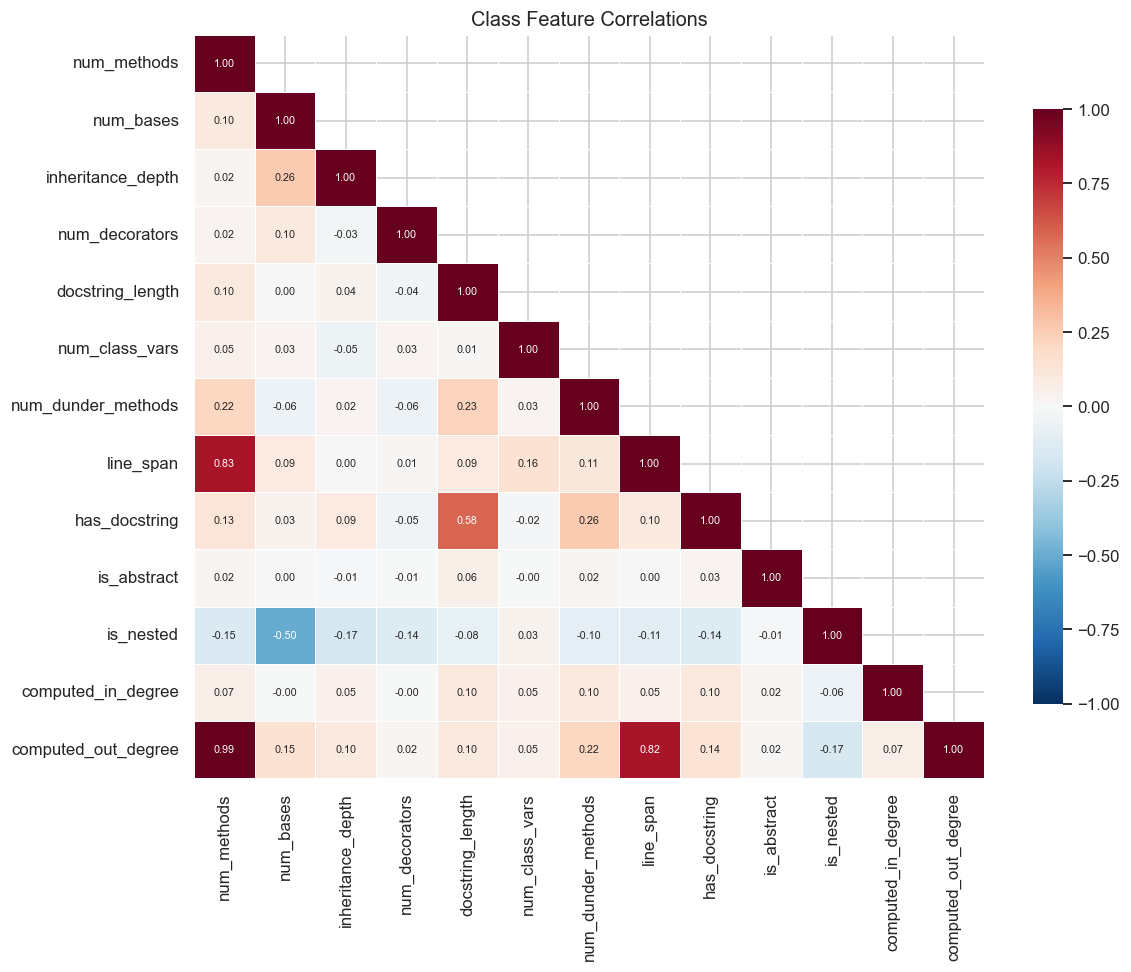

── Strong class feature pairs (|r| ≥ 0.70) ──


,feature_A,feature_B,r
0,num_methods,computed_out_degree,0.993
1,num_methods,line_span,0.826
2,line_span,computed_out_degree,0.822


In [24]:
# ── Cell 9: Feature Correlation Analysis ─────────────────────

def plot_corr_heatmap(df, features, title, figsize=(11, 9)):
    """Pearson correlation heatmap with a mask on the upper triangle."""
    data = df[features].copy()
    # Cast bool columns to float
    for col in data.select_dtypes(include="bool").columns:
        data[col] = data[col].astype(float)
    data = data.fillna(0)
    corr_mat = data.corr()
    mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_mat, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, annot_kws={"size": 7},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    return corr_mat

# helper to find strong pairs
def strong_pairs(corr_mat, threshold=0.7):
    upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    stack = upper.stack().rename("r").reset_index()
    stack.columns = ["feature_A", "feature_B", "r"]
    return stack[stack["r"].abs() >= threshold].sort_values("r", ascending=False, key=abs)

# ── 9a: Function features ──
func_corr_cols = [
    "num_params", "type_hint_coverage", "loc", "body_stmt_count",
    "cyclomatic_complexity", "nesting_depth", "num_local_vars",
    "num_returns", "num_yields", "num_raises", "num_calls_made",
    "docstring_length", "num_decorators",
    # boolean features cast to float
    "is_async", "is_staticmethod", "is_classmethod", "is_property",
    "is_abstractmethod", "is_dunder", "is_init", "is_private",
    "has_docstring", "has_return_annotation", "has_varargs", "has_kwargs",
    # graph features
    "computed_in_degree", "computed_out_degree",
]
func_corr_cols = [c for c in func_corr_cols if c in funcs.columns]
func_corr = plot_corr_heatmap(funcs, func_corr_cols, "Function Feature Correlations", figsize=(14, 12))

print("── Strong function feature pairs (|r| ≥ 0.70) ──")
func_strong = strong_pairs(func_corr, threshold=0.70)
display(func_strong.reset_index(drop=True).style.format({"r": "{:.3f}"}))

# ── 9b: Class features ──
class_corr_cols = [
    "num_methods", "num_bases", "inheritance_depth", "num_decorators",
    "docstring_length", "num_class_vars", "num_dunder_methods", "line_span",
    "has_docstring", "is_abstract", "is_nested",
    "computed_in_degree", "computed_out_degree",
]
class_corr_cols = [c for c in class_corr_cols if c in classes.columns]
class_corr = plot_corr_heatmap(classes, class_corr_cols, "Class Feature Correlations", figsize=(11, 9))

print("── Strong class feature pairs (|r| ≥ 0.70) ──")
class_strong = strong_pairs(class_corr, threshold=0.70)
display(class_strong.reset_index(drop=True).style.format({"r": "{:.3f}"}))
